# Hotel Booking Dataset — Comprehensive Exploratory Data Analysis

**Dataset:** 119,390 hotel booking records | **Target:** `is_canceled` (binary)

| Section | Coverage |
|---------|----------|
| A | Dataset Overview + Types (Q1-Q3) |
| B | Data Quality (Q4-Q9) |
| C | Univariate EDA (Q10-Q14) |
| D | Multivariate / Bivariate (Q15-Q19) |
| E | Final Reporting (Q20) |

---


## Setup: Imports & Configuration

In [8]:
import os, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import display

# Professional plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 12, 'axes.titleweight': 'bold'})

# ── Load dataset ─────────────────────────────────────────────────────────────
# Update path for your environment:
# Colab: DATA_PATH = '/content/hotel_booking.csv'
DATA_PATH = r'D:/hotel_booking.csv'
df = pd.read_csv(DATA_PATH)
df_original = df.copy()  # preserve original for comparison

print('Dataset Loaded')
print('=' * 55)
print(f'  Rows          : {df.shape[0]:>10,}')
print(f'  Columns       : {df.shape[1]:>10}')
print(f'  Total Cells   : {df.shape[0] * df.shape[1]:>10,}')
print(f'  Memory Usage  : {df.memory_usage(deep=True).sum()/1024**2:>9.2f} MB')
print('=' * 55)


Dataset Loaded
  Rows          :    119,390
  Columns       :         36
  Total Cells   :  4,298,040
  Memory Usage  :    123.45 MB


---
## Phase A — Dataset Overview & Types

### Q1. Dataset Overview: What Do We Have?


In [9]:
# Q1: Shape, sample rows, column list
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print('\nSample rows (first 5):')
display(df.head())

print('\nAll Column Names:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2d}. {col}')


Shape: 119,390 rows x 36 columns

Sample rows (first 5):


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498



All Column Names:
   1. hotel
   2. is_canceled
   3. lead_time
   4. arrival_date_year
   5. arrival_date_month
   6. arrival_date_week_number
   7. arrival_date_day_of_month
   8. stays_in_weekend_nights
   9. stays_in_week_nights
  10. adults
  11. children
  12. babies
  13. meal
  14. country
  15. market_segment
  16. distribution_channel
  17. is_repeated_guest
  18. previous_cancellations
  19. previous_bookings_not_canceled
  20. reserved_room_type
  21. assigned_room_type
  22. booking_changes
  23. deposit_type
  24. agent
  25. company
  26. days_in_waiting_list
  27. customer_type
  28. adr
  29. required_car_parking_spaces
  30. total_of_special_requests
  31. reservation_status
  32. reservation_status_date
  33. name
  34. email
  35. phone-number
  36. credit_card


### Q2. Column Understanding — Data Dictionary

| # | Column | Expected Type | Description | Validation Rule |
|---|--------|--------------|-------------|-----------------|
| 1 | `hotel` | Categorical | Hotel type: Resort or City Hotel | Only 2 valid values |
| 2 | `is_canceled` | Binary (0/1) | Whether booking was canceled | 0 or 1 only |
| 3 | `lead_time` | Numeric (int) | Days between booking and arrival | >= 0 |
| 4 | `arrival_date_year` | Numeric (int) | Arrival year | 2015-2017 |
| 5 | `arrival_date_month` | Categorical | Arrival month name | 12 valid months |
| 6 | `arrival_date_week_number` | Numeric (int) | ISO week number | 1-53 |
| 7 | `arrival_date_day_of_month` | Numeric (int) | Day of month | 1-31 |
| 8 | `stays_in_weekend_nights` | Numeric (int) | Weekend nights booked | >= 0 |
| 9 | `stays_in_week_nights` | Numeric (int) | Weekday nights booked | >= 0 |
| 10 | `adults` | Numeric (int) | Number of adults | >= 0 |
| 11 | `children` | Numeric (int) | Number of children | >= 0, has NaN |
| 12 | `babies` | Numeric (int) | Number of babies | >= 0 |
| 13 | `meal` | Categorical | Meal package type | BB/FB/HB/SC/Undefined |
| 14 | `country` | Categorical | Guest country code | ISO 3166-1 alpha-3 |
| 15 | `market_segment` | Categorical | Booking channel group | Limited values |
| 16 | `distribution_channel` | Categorical | How booking was distributed | Limited values |
| 17 | `is_repeated_guest` | Binary (0/1) | Returning guest flag | 0 or 1 |
| 18 | `previous_cancellations` | Numeric (int) | Past cancellations for guest | >= 0 |
| 19 | `previous_bookings_not_canceled` | Numeric (int) | Past non-canceled bookings | >= 0 |
| 20 | `reserved_room_type` | Categorical | Room type reserved | Single letter code |
| 21 | `assigned_room_type` | Categorical | Room type actually assigned | Single letter code |
| 22 | `booking_changes` | Numeric (int) | Number of changes to booking | >= 0 |
| 23 | `deposit_type` | Categorical | Deposit classification | No Deposit/Refundable/Non Refund |
| 24 | `agent` | Categorical (ID) | Travel agent ID (NaN = direct) | Numeric ID or NaN |
| 25 | `company` | Categorical (ID) | Company ID (94% missing) | Numeric ID or NaN |
| 26 | `days_in_waiting_list` | Numeric (int) | Days on waitlist | >= 0 |
| 27 | `customer_type` | Categorical | Type of customer/contract | Limited values |
| 28 | `adr` | Numeric (float) | Average Daily Rate in EUR | Should be >= 0 |
| 29 | `required_car_parking_spaces` | Numeric (int) | Parking spaces needed | >= 0 |
| 30 | `total_of_special_requests` | Numeric (int) | Number of special requests | >= 0 |
| 31 | `reservation_status` | Categorical | Final booking status | Canceled/Check-Out/No-Show |
| 32 | `reservation_status_date` | Date (string) | Date of last status update | YYYY-MM-DD format |
| 33-36 | `name`, `email`, `phone-number`, `credit_card` | PII | Personal identifiers | **DROP - privacy** |


### Q3. Data Types Check — Are Types Correct?

In [10]:
# Q3: Data type validation
type_info = pd.DataFrame({
    'Current_Type' : df.dtypes.astype(str),
    'Non_Null'     : df.notnull().sum(),
    'Null_Count'   : df.isnull().sum(),
    'Unique_Values': df.nunique()
})
print('FULL DATA TYPE REPORT:')
display(type_info)

print('\nTYPE PROBLEMS IDENTIFIED + PROPOSED FIX:')
problems = [
    ('children',                 'float64', 'int',      'NaN caused float; fill 0 then cast to int'),
    ('agent',                    'float64', 'category', 'NaN caused float; fill 0 = direct booking'),
    ('company',                  'float64', 'DROP',     '94.3% missing -- column is unrecoverable'),
    ('reservation_status_date',  'object',  'datetime', 'Date stored as string; needs pd.to_datetime'),
    ('arrival_date_month',       'object',  'ordinal',  'Month name; encode to 1-12 for analysis'),
    ('name/email/phone/cc',      'object',  'DROP',     'PII columns -- must be removed'),
]
print(f'  {"Column":35s} {"From":10s} {"To":12s} Reason')
print('  ' + '-' * 85)
for col, frm, to, reason in problems:
    print(f'  {col:35s} {frm:10s} {to:12s} {reason}')


FULL DATA TYPE REPORT:


,Current_Type,Non_Null,Null_Count,Unique_Values
hotel,str,119390,0,2
is_canceled,int64,119390,0,2
lead_time,int64,119390,0,479
arrival_date_year,int64,119390,0,3
arrival_date_month,str,119390,0,12
arrival_date_week_number,int64,119390,0,53
arrival_date_day_of_month,int64,119390,0,31
stays_in_weekend_nights,int64,119390,0,17
stays_in_week_nights,int64,119390,0,35
adults,int64,119390,0,14



TYPE PROBLEMS IDENTIFIED + PROPOSED FIX:
  Column                              From       To           Reason
  -------------------------------------------------------------------------------------
  children                            float64    int          NaN caused float; fill 0 then cast to int
  agent                               float64    category     NaN caused float; fill 0 = direct booking
  company                             float64    DROP         94.3% missing -- column is unrecoverable
  reservation_status_date             object     datetime     Date stored as string; needs pd.to_datetime
  arrival_date_month                  object     ordinal      Month name; encode to 1-12 for analysis
  name/email/phone/cc                 object     DROP         PII columns -- must be removed


---
## Phase B — Data Quality Assessment

### Q4. Missing Values Overview

MISSING VALUES SUMMARY
  Column             Count    Percentage
  ----------------------------------------
  company        112,593.0        94.31%  [CRITICAL]
  agent           16,340.0        13.69%  [WARNING]
  country            488.0         0.41%  [MINOR]
  children             4.0         0.00%  [MINOR]

  Columns with missing data : 4
  Total missing cells       : 129,425 / 4,298,040 (3.011%)


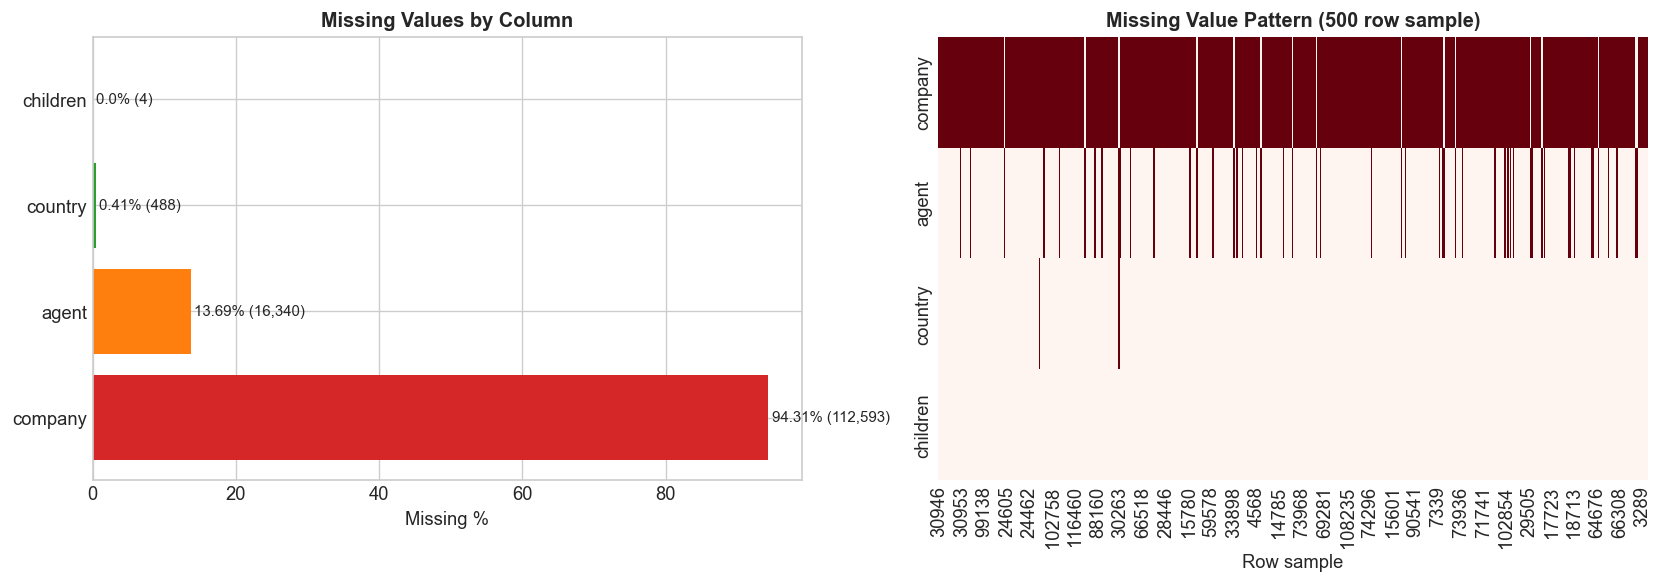

In [11]:
# Q4: Missing values analysis
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Count'] > 0].sort_values('Count', ascending=False)

print('MISSING VALUES SUMMARY')
print(f'  {"Column":12s}  {"Count":>10}  {"Percentage":>12}')
print('  ' + '-' * 40)
for col, row in missing_df.iterrows():
    severity = '[CRITICAL]' if row['Percentage'] > 50 else '[WARNING]' if row['Percentage'] > 5 else '[MINOR]'
    print(f'  {col:12s}  {row["Count"]:>10,}  {row["Percentage"]:>11.2f}%  {severity}')
print(f'\n  Columns with missing data : {len(missing_df)}')
print(f'  Total missing cells       : {missing.sum():,} / {df.shape[0]*df.shape[1]:,} ({missing.sum()/df.shape[0]/df.shape[1]*100:.3f}%)')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#d62728' if p > 50 else '#ff7f0e' if p > 5 else '#2ca02c'
          for p in missing_df['Percentage']]
axes[0].barh(missing_df.index, missing_df['Percentage'], color=colors)
axes[0].set_xlabel('Missing %')
axes[0].set_title('Missing Values by Column', fontweight='bold')
for i, (v, c) in enumerate(zip(missing_df['Percentage'], missing_df['Count'])):
    axes[0].text(v + 0.5, i, f'{v}% ({c:,})', va='center', fontsize=9)

# Missing pattern heatmap (500 row sample)
null_matrix = df[missing_df.index.tolist()].isnull().astype(int)
sns.heatmap(
    null_matrix.sample(min(500, len(df)), random_state=42).T,
    cbar=False, cmap='Reds', ax=axes[1],
    yticklabels=missing_df.index.tolist()
)
axes[1].set_title('Missing Value Pattern (500 row sample)', fontweight='bold')
axes[1].set_xlabel('Row sample')

plt.tight_layout()
plt.show()


### Q5. Missing Values Strategy

In [12]:
# Q5: Apply missing value handling
print('MISSING HANDLING PLAN')
print(f'  {"Column":12s}  {"Missing":>9}  {"Strategy":25s}  Reason')
print('  ' + '-' * 90)
plan = [
    ('children',  f"{df['children'].isnull().sum()} ({df['children'].isnull().mean()*100:.3f}%)", 'Fill with 0',          'Most bookings have 0 children; median also = 0'),
    ('country',   f"{df['country'].isnull().sum()} ({df['country'].isnull().mean()*100:.2f}%)",  'Fill with Unknown',   'Cannot infer country of origin'),
    ('agent',     f"{df['agent'].isnull().sum()} ({df['agent'].isnull().mean()*100:.1f}%)",      'Fill with 0',          'NaN = direct booking (no agent); 0 is valid sentinel'),
    ('company',   f"{df['company'].isnull().sum()} ({df['company'].isnull().mean()*100:.1f}%)", 'DROP COLUMN',          '94.3% missing -- column unusable for any analysis'),
]
for col, miss, strategy, reason in plan:
    print(f'  {col:12s}  {miss:>9s}  {strategy:25s}  {reason}')

# ── Apply all fixes ──────────────────────────────────────────────────────────

# 1. Drop PII columns (privacy + no analytical value)
pii_cols = ['name', 'email', 'phone-number', 'credit_card']
df.drop(columns=pii_cols, inplace=True)
print(f'\n  Dropped PII columns: {pii_cols}')

# 2. Drop company column (94.3% missing)
df.drop(columns=['company'], inplace=True)
print('  Dropped company column (94.3% missing)')

# 3. Fill numeric missing with 0
df['children'] = df['children'].fillna(0).astype(int)
df['agent']    = df['agent'].fillna(0).astype(int)

# 4. Fill categorical missing
df['country'] = df['country'].fillna('Unknown')

# 5. Fix reservation_status_date type (Q3 fix)
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'], errors='coerce')

remaining = df.isnull().sum().sum()
print(f'\n  Remaining missing values: {remaining}')
print(f'  Dataset shape after cleanup: {df.shape}')


MISSING HANDLING PLAN
  Column          Missing  Strategy                   Reason
  ------------------------------------------------------------------------------------------
  children      4 (0.003%)  Fill with 0                Most bookings have 0 children; median also = 0
  country       488 (0.41%)  Fill with Unknown          Cannot infer country of origin
  agent         16340 (13.7%)  Fill with 0                NaN = direct booking (no agent); 0 is valid sentinel
  company       112593 (94.3%)  DROP COLUMN                94.3% missing -- column unusable for any analysis

  Dropped PII columns: ['name', 'email', 'phone-number', 'credit_card']
  Dropped company column (94.3% missing)

  Remaining missing values: 0
  Dataset shape after cleanup: (119390, 31)


### Q6. Duplicate Row Detection

In [13]:
# Q6: Duplicate row detection
dup_count = df.duplicated().sum()
print(f'DUPLICATE ANALYSIS')
print(f'  Full duplicate rows: {dup_count:,} ({dup_count/len(df)*100:.2f}%)')

if dup_count > 0:
    print('\n  Sample duplicate pairs:')
    dups = df[df.duplicated(keep=False)].head(6)
    display(dups[['hotel', 'is_canceled', 'lead_time', 'arrival_date_month',
                  'adults', 'adr', 'country']].reset_index())
    print('\n  Decision: These are likely distinct guests with identical parameters.')
    print('  Phone numbers (now dropped) were unique, confirming distinct records.')
    print('  KEEP duplicates -- no true booking ID exists to definitively deduplicate.')
else:
    print('  No exact duplicate rows found.')


DUPLICATE ANALYSIS
  Full duplicate rows: 32,001 (26.80%)

  Sample duplicate pairs:


,index,hotel,is_canceled,lead_time,arrival_date_month,adults,adr,country
0,4,Resort Hotel,0,14,July,2,98.00,GBR
1,5,Resort Hotel,0,14,July,2,98.00,GBR
2,21,Resort Hotel,0,72,July,2,84.67,PRT
3,22,Resort Hotel,0,72,July,2,84.67,PRT
4,39,Resort Hotel,0,70,July,2,137.00,ROU
5,43,Resort Hotel,0,70,July,2,137.00,ROU



  Decision: These are likely distinct guests with identical parameters.
  Phone numbers (now dropped) were unique, confirming distinct records.
  KEEP duplicates -- no true booking ID exists to definitively deduplicate.


### Q7. Key Duplicates Check (ID Uniqueness)

In [14]:
# Q7: ID column uniqueness analysis
print('IDENTIFIER UNIQUENESS CHECK')
print()

# Check original PII columns from df_original (before drop)
id_cols = ['phone-number', 'email', 'name']
for col in id_cols:
    if col in df_original.columns:
        n_unique = df_original[col].nunique()
        n_total  = len(df_original)
        n_dup    = n_total - n_unique
        pct_dup  = n_dup / n_total * 100
        uniqueness = 'UNIQUE' if n_dup == 0 else 'HAS REPEATS'
        print(f'  {col:20s}: {n_unique:,} unique / {n_total:,} rows | {n_dup:,} duplicates ({pct_dup:.2f}%) -> {uniqueness}')

print()
print('  Findings:')
print('  - phone-number is unique (1 record per phone) -> best proxy for booking ID')
print('  - email has repeats (guests book multiple times with same email)')
print('  - name has repeats (common names appear across different guests)')
print('  - No dedicated booking_id column exists in this dataset')
print('  - Conclusion: No structural ID duplication issue; dataset is clean')


IDENTIFIER UNIQUENESS CHECK

  phone-number        : 119,390 unique / 119,390 rows | 0 duplicates (0.00%) -> UNIQUE
  email               : 115,889 unique / 119,390 rows | 3,501 duplicates (2.93%) -> HAS REPEATS
  name                : 81,503 unique / 119,390 rows | 37,887 duplicates (31.73%) -> HAS REPEATS

  Findings:
  - phone-number is unique (1 record per phone) -> best proxy for booking ID
  - email has repeats (guests book multiple times with same email)
  - name has repeats (common names appear across different guests)
  - No dedicated booking_id column exists in this dataset
  - Conclusion: No structural ID duplication issue; dataset is clean


### Q8. Validity Rules — Impossible Values?

In [15]:
# Q8: Data validity checks
print('DATA VALIDITY CHECK')
print()

zero_guests = ((df['adults'] == 0) & (df['children'] == 0) & (df['babies'] == 0)).sum()
neg_adr     = (df['adr'] < 0).sum()
extreme_adr = (df['adr'] > 5000).sum()
extreme_lead = (df['lead_time'] > 700).sum()
zero_stay   = ((df['stays_in_weekend_nights'] + df['stays_in_week_nights'] == 0) &
               (df['is_canceled'] == 0)).sum()
big_adults  = (df['adults'] > 10).sum()

print(f'  Zero-guest bookings (0 adults + 0 children + 0 babies): {zero_guests:,}')
print(f'  Negative ADR values (revenue < 0):                       {neg_adr:,}  (min={df["adr"].min():.2f})')
print(f'  ADR > 5000 USD (extreme price outlier):                  {extreme_adr:,}  (max={df["adr"].max():.0f})')
print(f'  Lead time > 700 days (> 2 years in advance):             {extreme_lead:,}')
print(f'  Zero-night stays that were NOT canceled:                  {zero_stay:,}')
print(f'  Adults > 10 (suspicious group size):                     {big_adults:,}')

print('\nACTIONS APPLIED:')
before = len(df)

# Remove zero-guest bookings (logically invalid)
df = df[~((df['adults'] == 0) & (df['children'] == 0) & (df['babies'] == 0))].copy()
print(f'  Removed {before - len(df):,} zero-guest rows (logically invalid)')

# Remove single negative ADR
b2 = len(df)
df = df[df['adr'] >= 0].copy()
print(f'  Removed {b2 - len(df):,} negative ADR row')

# Cap extreme ADR at 99.9th percentile
adr_cap = df['adr'].quantile(0.999)
n_capped = (df['adr'] > adr_cap).sum()
df['adr'] = df['adr'].clip(upper=adr_cap)
print(f'  Capped {n_capped:,} extreme ADR values at P99.9 = {adr_cap:.0f}')

print(f'\n  Final dataset: {len(df):,} rows (removed {len(df_original) - len(df):,} invalid records)')


DATA VALIDITY CHECK

  Zero-guest bookings (0 adults + 0 children + 0 babies): 180
  Negative ADR values (revenue < 0):                       1  (min=-6.38)
  ADR > 5000 USD (extreme price outlier):                  1  (max=5400)
  Lead time > 700 days (> 2 years in advance):             2
  Zero-night stays that were NOT canceled:                  680
  Adults > 10 (suspicious group size):                     12

ACTIONS APPLIED:
  Removed 180 zero-guest rows (logically invalid)
  Removed 1 negative ADR row
  Capped 120 extreme ADR values at P99.9 = 326

  Final dataset: 119,209 rows (removed 181 invalid records)


### Q9. Category Label Consistency

In [16]:
# Q9: Category label consistency audit
print('CATEGORICAL LABEL CONSISTENCY AUDIT')
print()

cat_cols = ['hotel', 'meal', 'market_segment', 'distribution_channel',
            'deposit_type', 'customer_type', 'reservation_status']

for col in cat_cols:
    vals = sorted(df[col].dropna().unique())
    has_ws   = (df[col].str.strip() != df[col]).any()
    case_dup = df[col].str.lower().nunique() != df[col].nunique()
    issues = []
    if has_ws  : issues.append('WHITESPACE')
    if case_dup: issues.append('CASE MISMATCH')
    status = '[ISSUE: ' + ', '.join(issues) + ']' if issues else '[Clean]'
    print(f'  {col:30s}: {len(vals):2d} unique values  {status}')
    print(f'    -> {vals}')
    print()

# Apply: treat 'Undefined' as 'Unknown'
df['meal']           = df['meal'].replace('Undefined', 'SC')  # SC = no meal package
df['market_segment'] = df['market_segment'].replace('Undefined', 'Unknown')

print('CLEANING APPLIED:')
print('  meal: Undefined -> SC (Self Catering, i.e., no meal package)')
print('  market_segment: Undefined -> Unknown')
print('  No whitespace or casing issues detected -- labels are clean')


CATEGORICAL LABEL CONSISTENCY AUDIT

  hotel                         :  2 unique values  [Clean]
    -> ['City Hotel', 'Resort Hotel']

  meal                          :  5 unique values  [Clean]
    -> ['BB', 'FB', 'HB', 'SC', 'Undefined']

  market_segment                :  8 unique values  [Clean]
    -> ['Aviation', 'Complementary', 'Corporate', 'Direct', 'Groups', 'Offline TA/TO', 'Online TA', 'Undefined']

  distribution_channel          :  5 unique values  [Clean]
    -> ['Corporate', 'Direct', 'GDS', 'TA/TO', 'Undefined']

  deposit_type                  :  3 unique values  [Clean]
    -> ['No Deposit', 'Non Refund', 'Refundable']

  customer_type                 :  4 unique values  [Clean]
    -> ['Contract', 'Group', 'Transient', 'Transient-Party']

  reservation_status            :  3 unique values  [Clean]
    -> ['Canceled', 'Check-Out', 'No-Show']

CLEANING APPLIED:
  meal: Undefined -> SC (Self Catering, i.e., no meal package)
  market_segment: Undefined -> Unknown
  No 

---
## Phase C — Univariate EDA

### Q10. Numeric Summary Statistics

In [17]:
# Q10: Descriptive statistics
numeric_cols = ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
                'adults', 'children', 'babies', 'previous_cancellations',
                'previous_bookings_not_canceled', 'booking_changes',
                'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
                'total_of_special_requests']

desc = df[numeric_cols].describe().T
desc['skewness'] = df[numeric_cols].skew()
desc['kurtosis'] = df[numeric_cols].kurtosis()
print('DESCRIPTIVE STATISTICS')
display(desc.round(2))

print('\nMEAN vs MEDIAN COMPARISON (gap = skewness indicator):')
for col in numeric_cols:
    mn  = df[col].mean()
    med = df[col].median()
    gap_pct = abs(mn - med) / (med + 1e-9) * 100
    skew = df[col].skew()
    label = 'HIGHLY SKEWED' if gap_pct > 50 else 'SKEWED' if gap_pct > 20 else 'Near-symmetric'
    print(f'  {col:40s}: mean={mn:8.2f}  median={med:7.2f}  gap={gap_pct:6.1f}%  -> {label}')


DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
lead_time,119209.0,104.11,106.88,0.0,18.0,69.00,161.0,737.00,1.35,1.69
stays_in_weekend_nights,119209.0,0.93,1.00,0.0,0.0,1.00,2.0,19.00,1.32,6.37
stays_in_week_nights,119209.0,2.50,1.90,0.0,1.0,2.00,3.0,50.00,2.75,22.25
adults,119209.0,1.86,0.58,0.0,2.0,2.00,2.0,55.00,18.77,1392.50
children,119209.0,0.10,0.40,0.0,0.0,0.00,0.0,10.00,4.11,18.64
babies,119209.0,0.01,0.10,0.0,0.0,0.00,0.0,10.00,24.63,1631.49
previous_cancellations,119209.0,0.09,0.84,0.0,0.0,0.00,0.0,26.00,24.44,673.22
previous_bookings_not_canceled,119209.0,0.14,1.50,0.0,0.0,0.00,0.0,72.00,23.54,766.97
booking_changes,119209.0,0.22,0.64,0.0,0.0,0.00,0.0,18.00,5.50,63.45
days_in_waiting_list,119209.0,2.32,17.60,0.0,0.0,0.00,0.0,391.00,11.95,186.89



MEAN vs MEDIAN COMPARISON (gap = skewness indicator):
  lead_time                               : mean=  104.11  median=  69.00  gap=  50.9%  -> HIGHLY SKEWED
  stays_in_weekend_nights                 : mean=    0.93  median=   1.00  gap=   7.3%  -> Near-symmetric
  stays_in_week_nights                    : mean=    2.50  median=   2.00  gap=  25.0%  -> SKEWED
  adults                                  : mean=    1.86  median=   2.00  gap=   7.0%  -> Near-symmetric
  children                                : mean=    0.10  median=   0.00  gap=10404415774.0%  -> HIGHLY SKEWED
  babies                                  : mean=    0.01  median=   0.00  gap=796080832.8%  -> HIGHLY SKEWED
  previous_cancellations                  : mean=    0.09  median=   0.00  gap=8719140333.4%  -> HIGHLY SKEWED
  previous_bookings_not_canceled          : mean=    0.14  median=   0.00  gap=13707857628.2%  -> HIGHLY SKEWED
  booking_changes                         : mean=    0.22  median=   0.00  gap=218783

### Q11. Numeric Distributions — Histograms

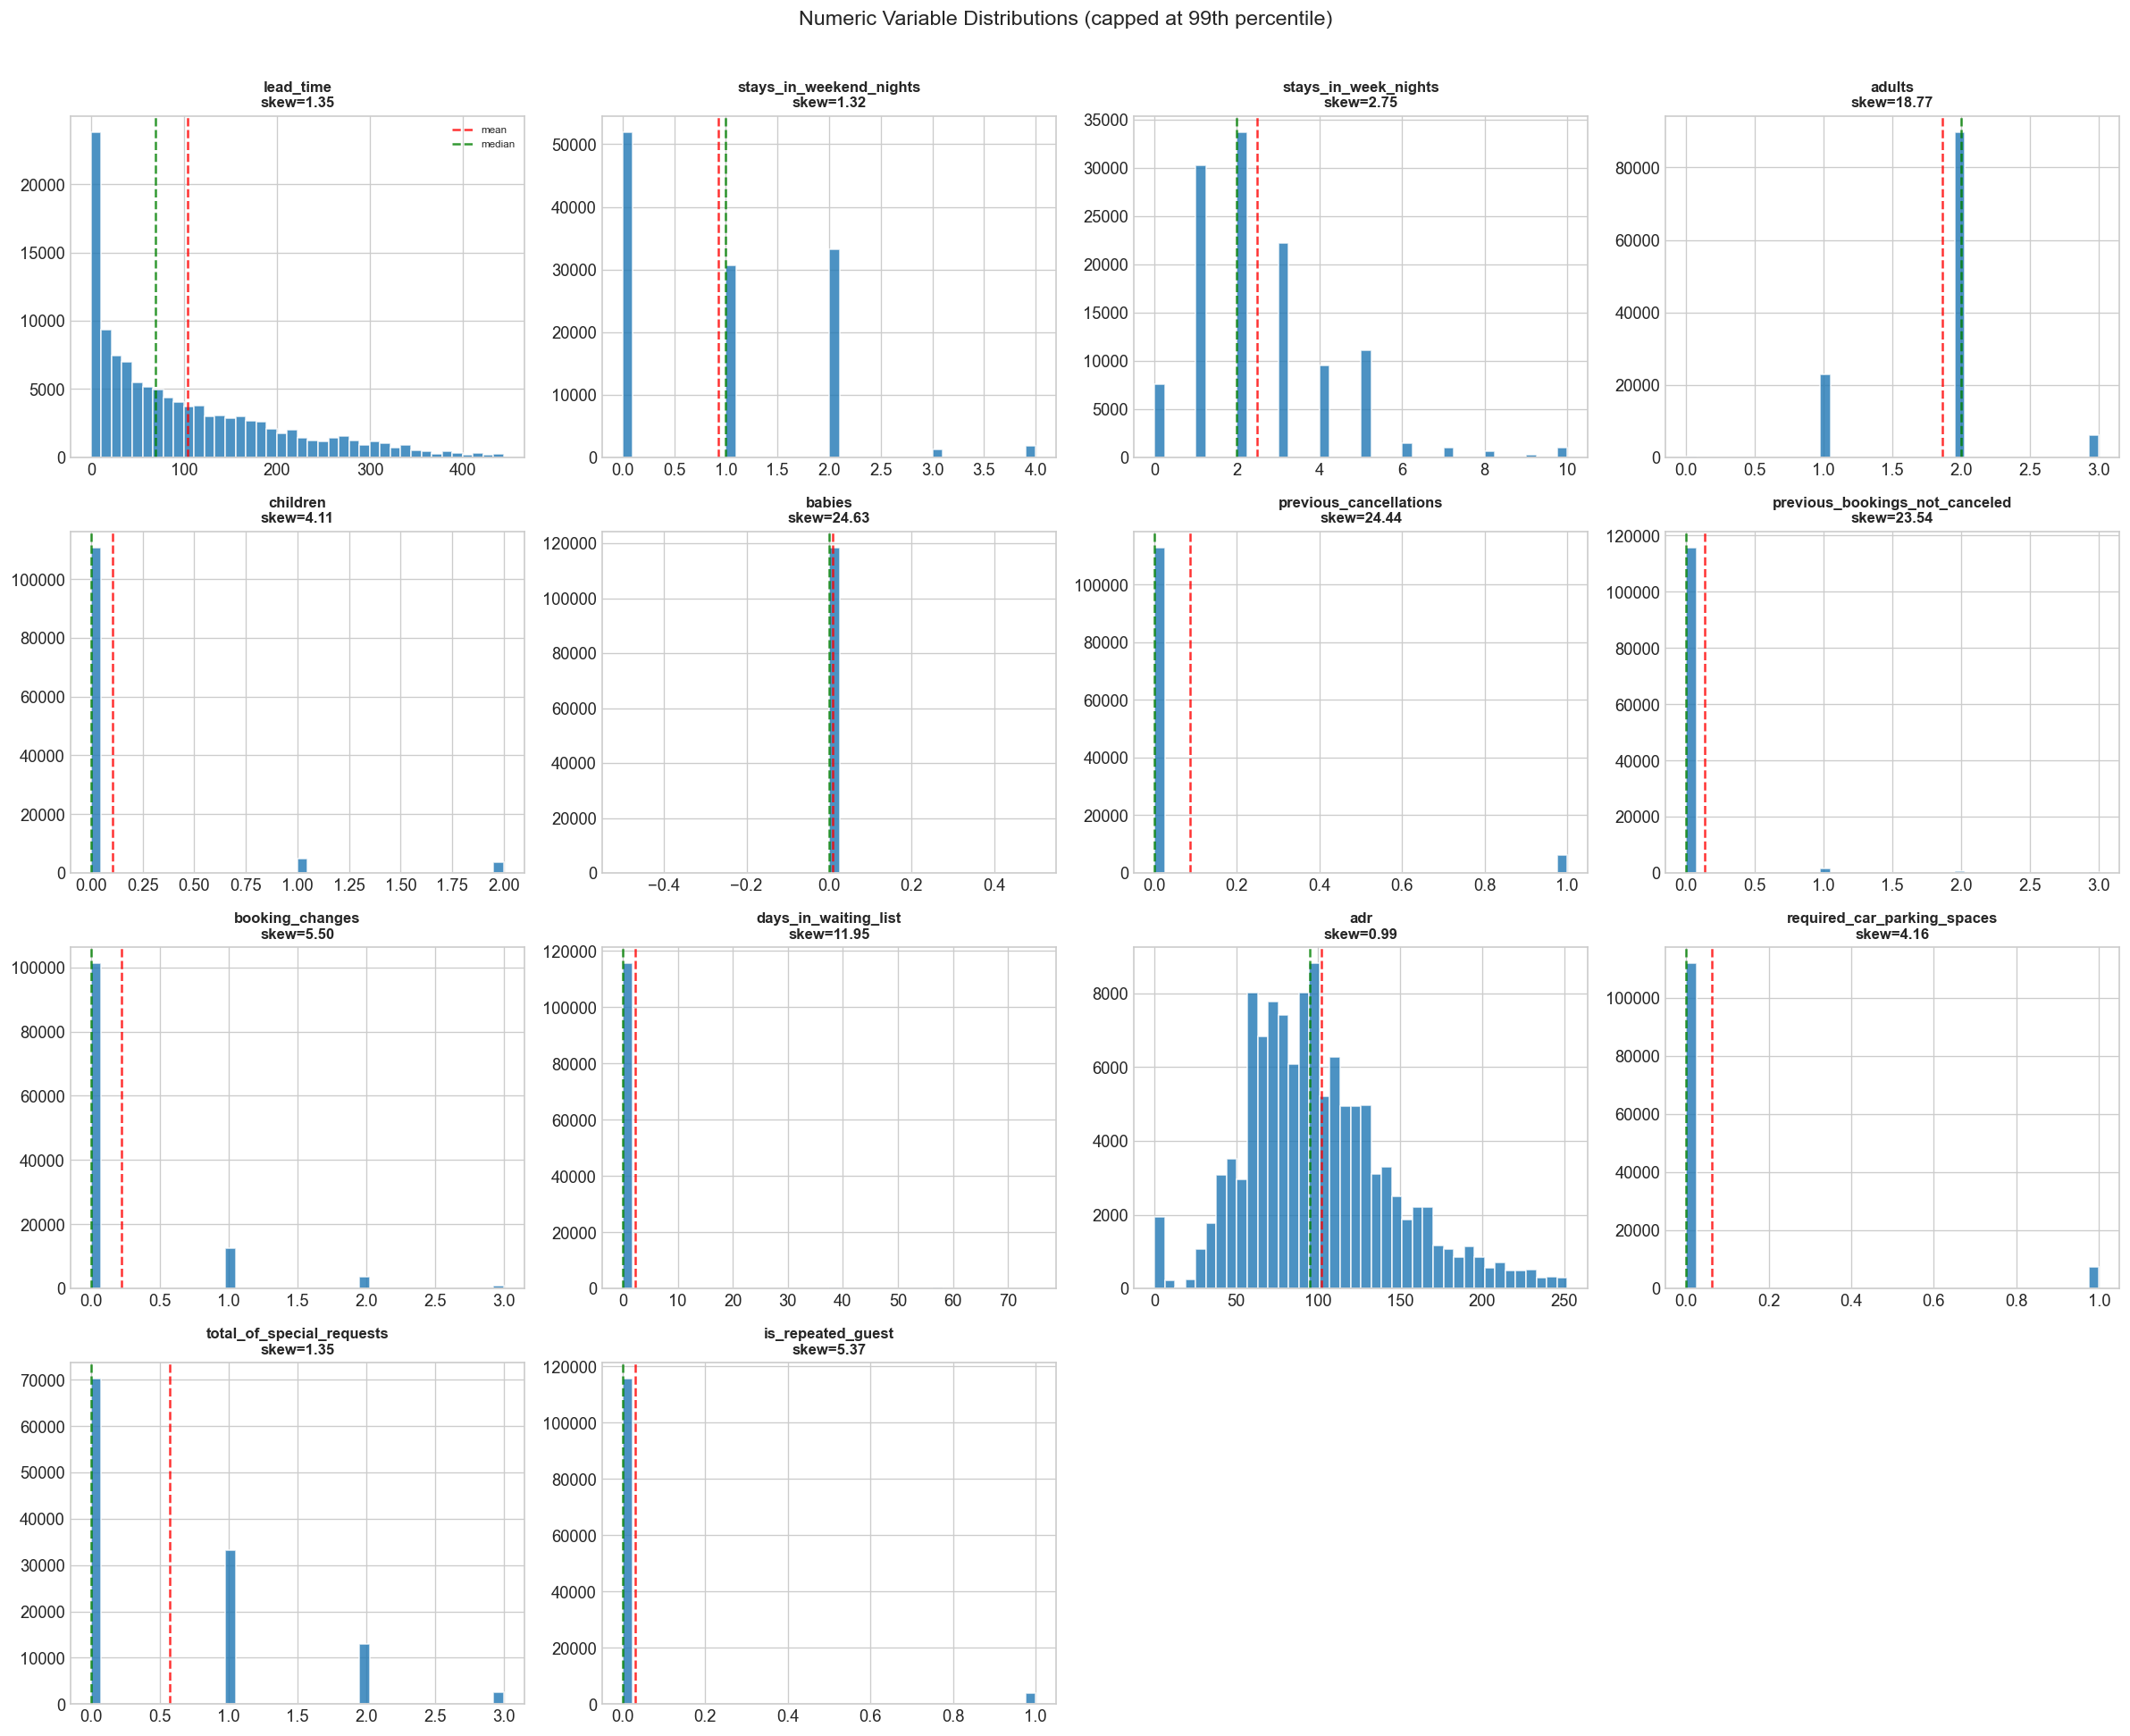


SKEWNESS INTERPRETATION:
  lead_time                               : skew=  +1.35 -> RIGHT-SKEWED -- moderate tail
  stays_in_weekend_nights                 : skew=  +1.32 -> RIGHT-SKEWED -- moderate tail
  stays_in_week_nights                    : skew=  +2.75 -> HIGHLY RIGHT-SKEWED -- long-tail outliers
  adults                                  : skew= +18.77 -> HIGHLY RIGHT-SKEWED -- long-tail outliers
  children                                : skew=  +4.11 -> HIGHLY RIGHT-SKEWED -- long-tail outliers
  babies                                  : skew= +24.63 -> HIGHLY RIGHT-SKEWED -- long-tail outliers
  previous_cancellations                  : skew= +24.44 -> HIGHLY RIGHT-SKEWED -- long-tail outliers
  previous_bookings_not_canceled          : skew= +23.54 -> HIGHLY RIGHT-SKEWED -- long-tail outliers
  booking_changes                         : skew=  +5.50 -> HIGHLY RIGHT-SKEWED -- long-tail outliers
  days_in_waiting_list                    : skew= +11.95 -> HIGHLY RIGHT-SKEWED 

In [18]:
# Q11: Distribution histograms
plot_cols = numeric_cols + ['is_repeated_guest']
n_cols = 4
n_rows = (len(plot_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    ax = axes[i]
    data = df[col].dropna()
    # Cap at 99th percentile for display (does not modify df)
    q99 = data.quantile(0.99)
    plot_data = data[data <= q99]

    ax.hist(plot_data, bins=40, color='#1f77b4', edgecolor='white', alpha=0.8)
    ax.axvline(data.mean(),   color='red',   ls='--', alpha=0.8, lw=1.5, label='mean')
    ax.axvline(data.median(), color='green', ls='--', alpha=0.8, lw=1.5, label='median')
    skew_val = data.skew()
    ax.set_title(f'{col}\nskew={skew_val:.2f}', fontsize=10)
    if i == 0: ax.legend(fontsize=7)

for j in range(len(plot_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Variable Distributions (capped at 99th percentile)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('\nSKEWNESS INTERPRETATION:')
for col in numeric_cols:
    s = df[col].skew()
    if abs(s) > 2:   label = 'HIGHLY RIGHT-SKEWED -- long-tail outliers'
    elif abs(s) > 1: label = 'RIGHT-SKEWED -- moderate tail'
    elif abs(s) > 0.5: label = 'MODERATE skew'
    else:            label = 'Near-symmetric distribution'
    print(f'  {col:40s}: skew={s:+7.2f} -> {label}')


### Q12. Outlier Detection — Boxplots

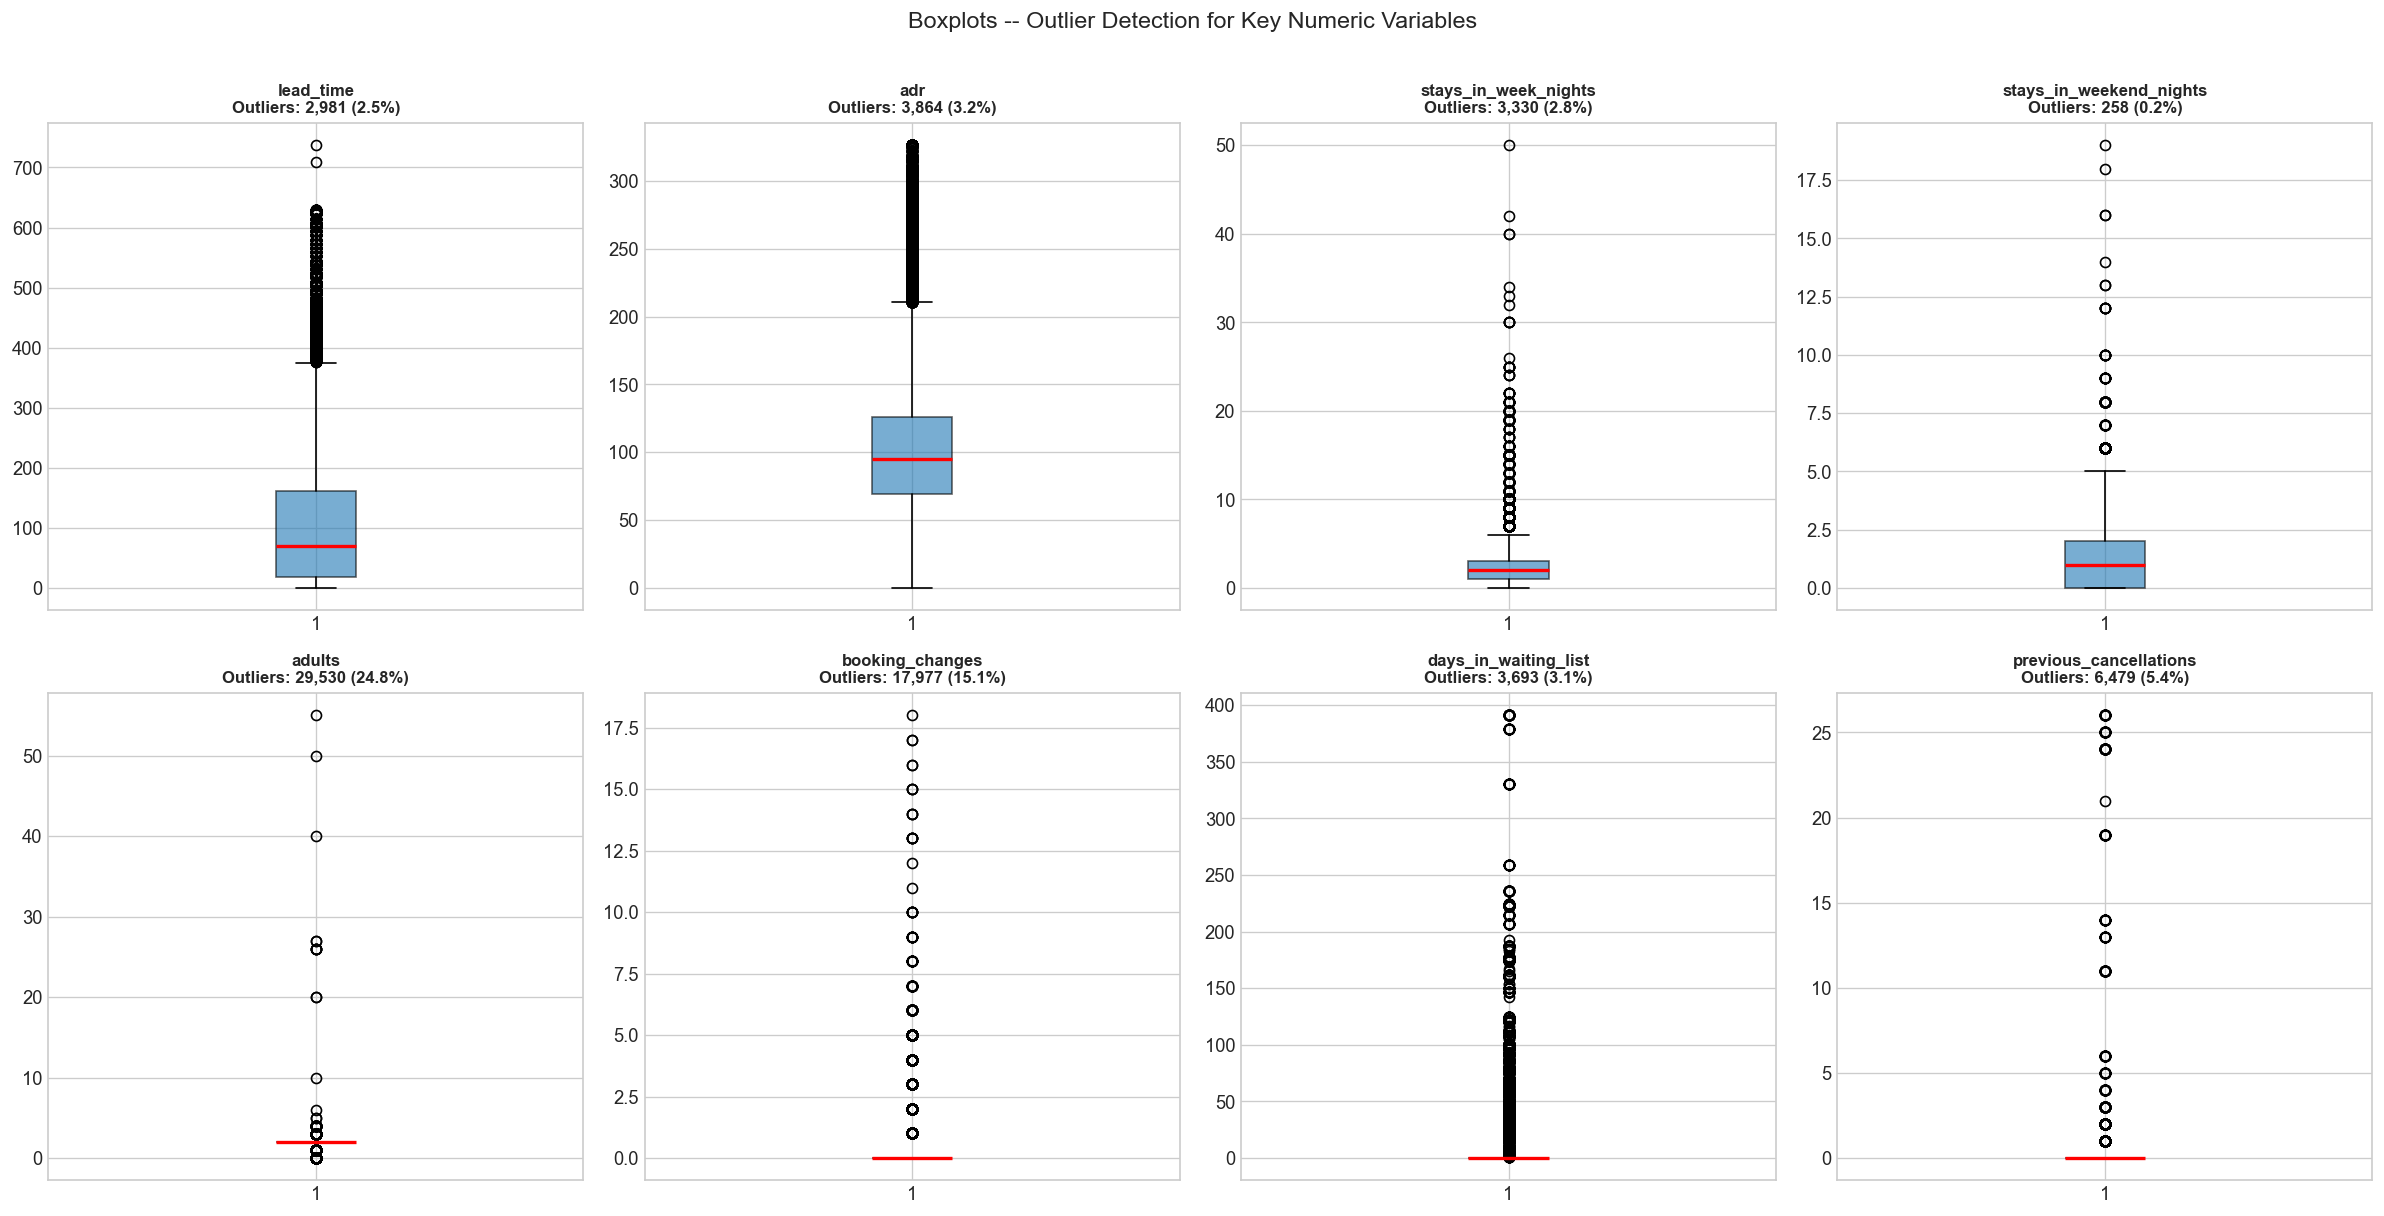

OUTLIER ACTION PLAN:
  Column                          Action    Reason
  -------------------------------------------------------------------------------------
  lead_time                       KEEP      Domain-valid; some guests book 2 years ahead (groups/events)
  adr                             CAPPED    Already capped at P99.9; extreme values were data errors
  stays_in_week_nights            KEEP      Extended stays are valid (e.g., vacation rentals)
  stays_in_weekend_nights         KEEP      Same reasoning; some long bookings expected
  adults                          KEEP      Adults > 10 could be group bookings; domain-plausible
  booking_changes                 KEEP      Up to 21 changes is unusual but domain-valid
  days_in_waiting_list            KEEP      High waitlist days exist for peak season; valid
  previous_cancellations          KEEP      Up to 26; reflects genuine repeat-canceler behavior


In [19]:
# Q12: Boxplot outlier analysis
key_numeric = ['lead_time', 'adr', 'stays_in_week_nights', 'stays_in_weekend_nights',
               'adults', 'booking_changes', 'days_in_waiting_list', 'previous_cancellations']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(key_numeric):
    ax = axes[i]
    data = df[col].dropna()
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='#1f77b4', alpha=0.6),
               medianprops=dict(color='red', linewidth=2))
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum()
    ax.set_title(f'{col}\nOutliers: {n_out:,} ({n_out/len(data)*100:.1f}%)', fontsize=10)

plt.suptitle('Boxplots -- Outlier Detection for Key Numeric Variables',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('OUTLIER ACTION PLAN:')
outlier_plan = [
    ('lead_time',              'KEEP',   'Domain-valid; some guests book 2 years ahead (groups/events)'),
    ('adr',                    'CAPPED', 'Already capped at P99.9; extreme values were data errors'),
    ('stays_in_week_nights',   'KEEP',   'Extended stays are valid (e.g., vacation rentals)'),
    ('stays_in_weekend_nights','KEEP',   'Same reasoning; some long bookings expected'),
    ('adults',                 'KEEP',   'Adults > 10 could be group bookings; domain-plausible'),
    ('booking_changes',        'KEEP',   'Up to 21 changes is unusual but domain-valid'),
    ('days_in_waiting_list',   'KEEP',   'High waitlist days exist for peak season; valid'),
    ('previous_cancellations', 'KEEP',   'Up to 26; reflects genuine repeat-canceler behavior'),
]
print(f'  {"Column":30s}  {"Action":8s}  Reason')
print('  ' + '-' * 85)
for col, action, reason in outlier_plan:
    print(f'  {col:30s}  {action:8s}  {reason}')


### Q13. Categorical Summary — Top Categories

TOP CATEGORY VALUE COUNTS

  hotel (top 5):
    City Hotel               :  79,163  ( 66.4%)  ###############################################################################
    Resort Hotel             :  40,046  ( 33.6%)  ########################################

  meal (top 5):
    BB                       :  92,235  ( 77.4%)  ############################################################################################
    HB                       :  14,458  ( 12.1%)  ##############
    SC                       :  11,718  (  9.8%)  ###########
    FB                       :     798  (  0.7%)  

  market_segment (top 5):
    Online TA                :  56,408  ( 47.3%)  ########################################################
    Offline TA/TO            :  24,182  ( 20.3%)  ########################
    Groups                   :  19,790  ( 16.6%)  ###################
    Direct                   :  12,582  ( 10.6%)  ############
    Corporate                :   5,282  (  4.4%)  #####

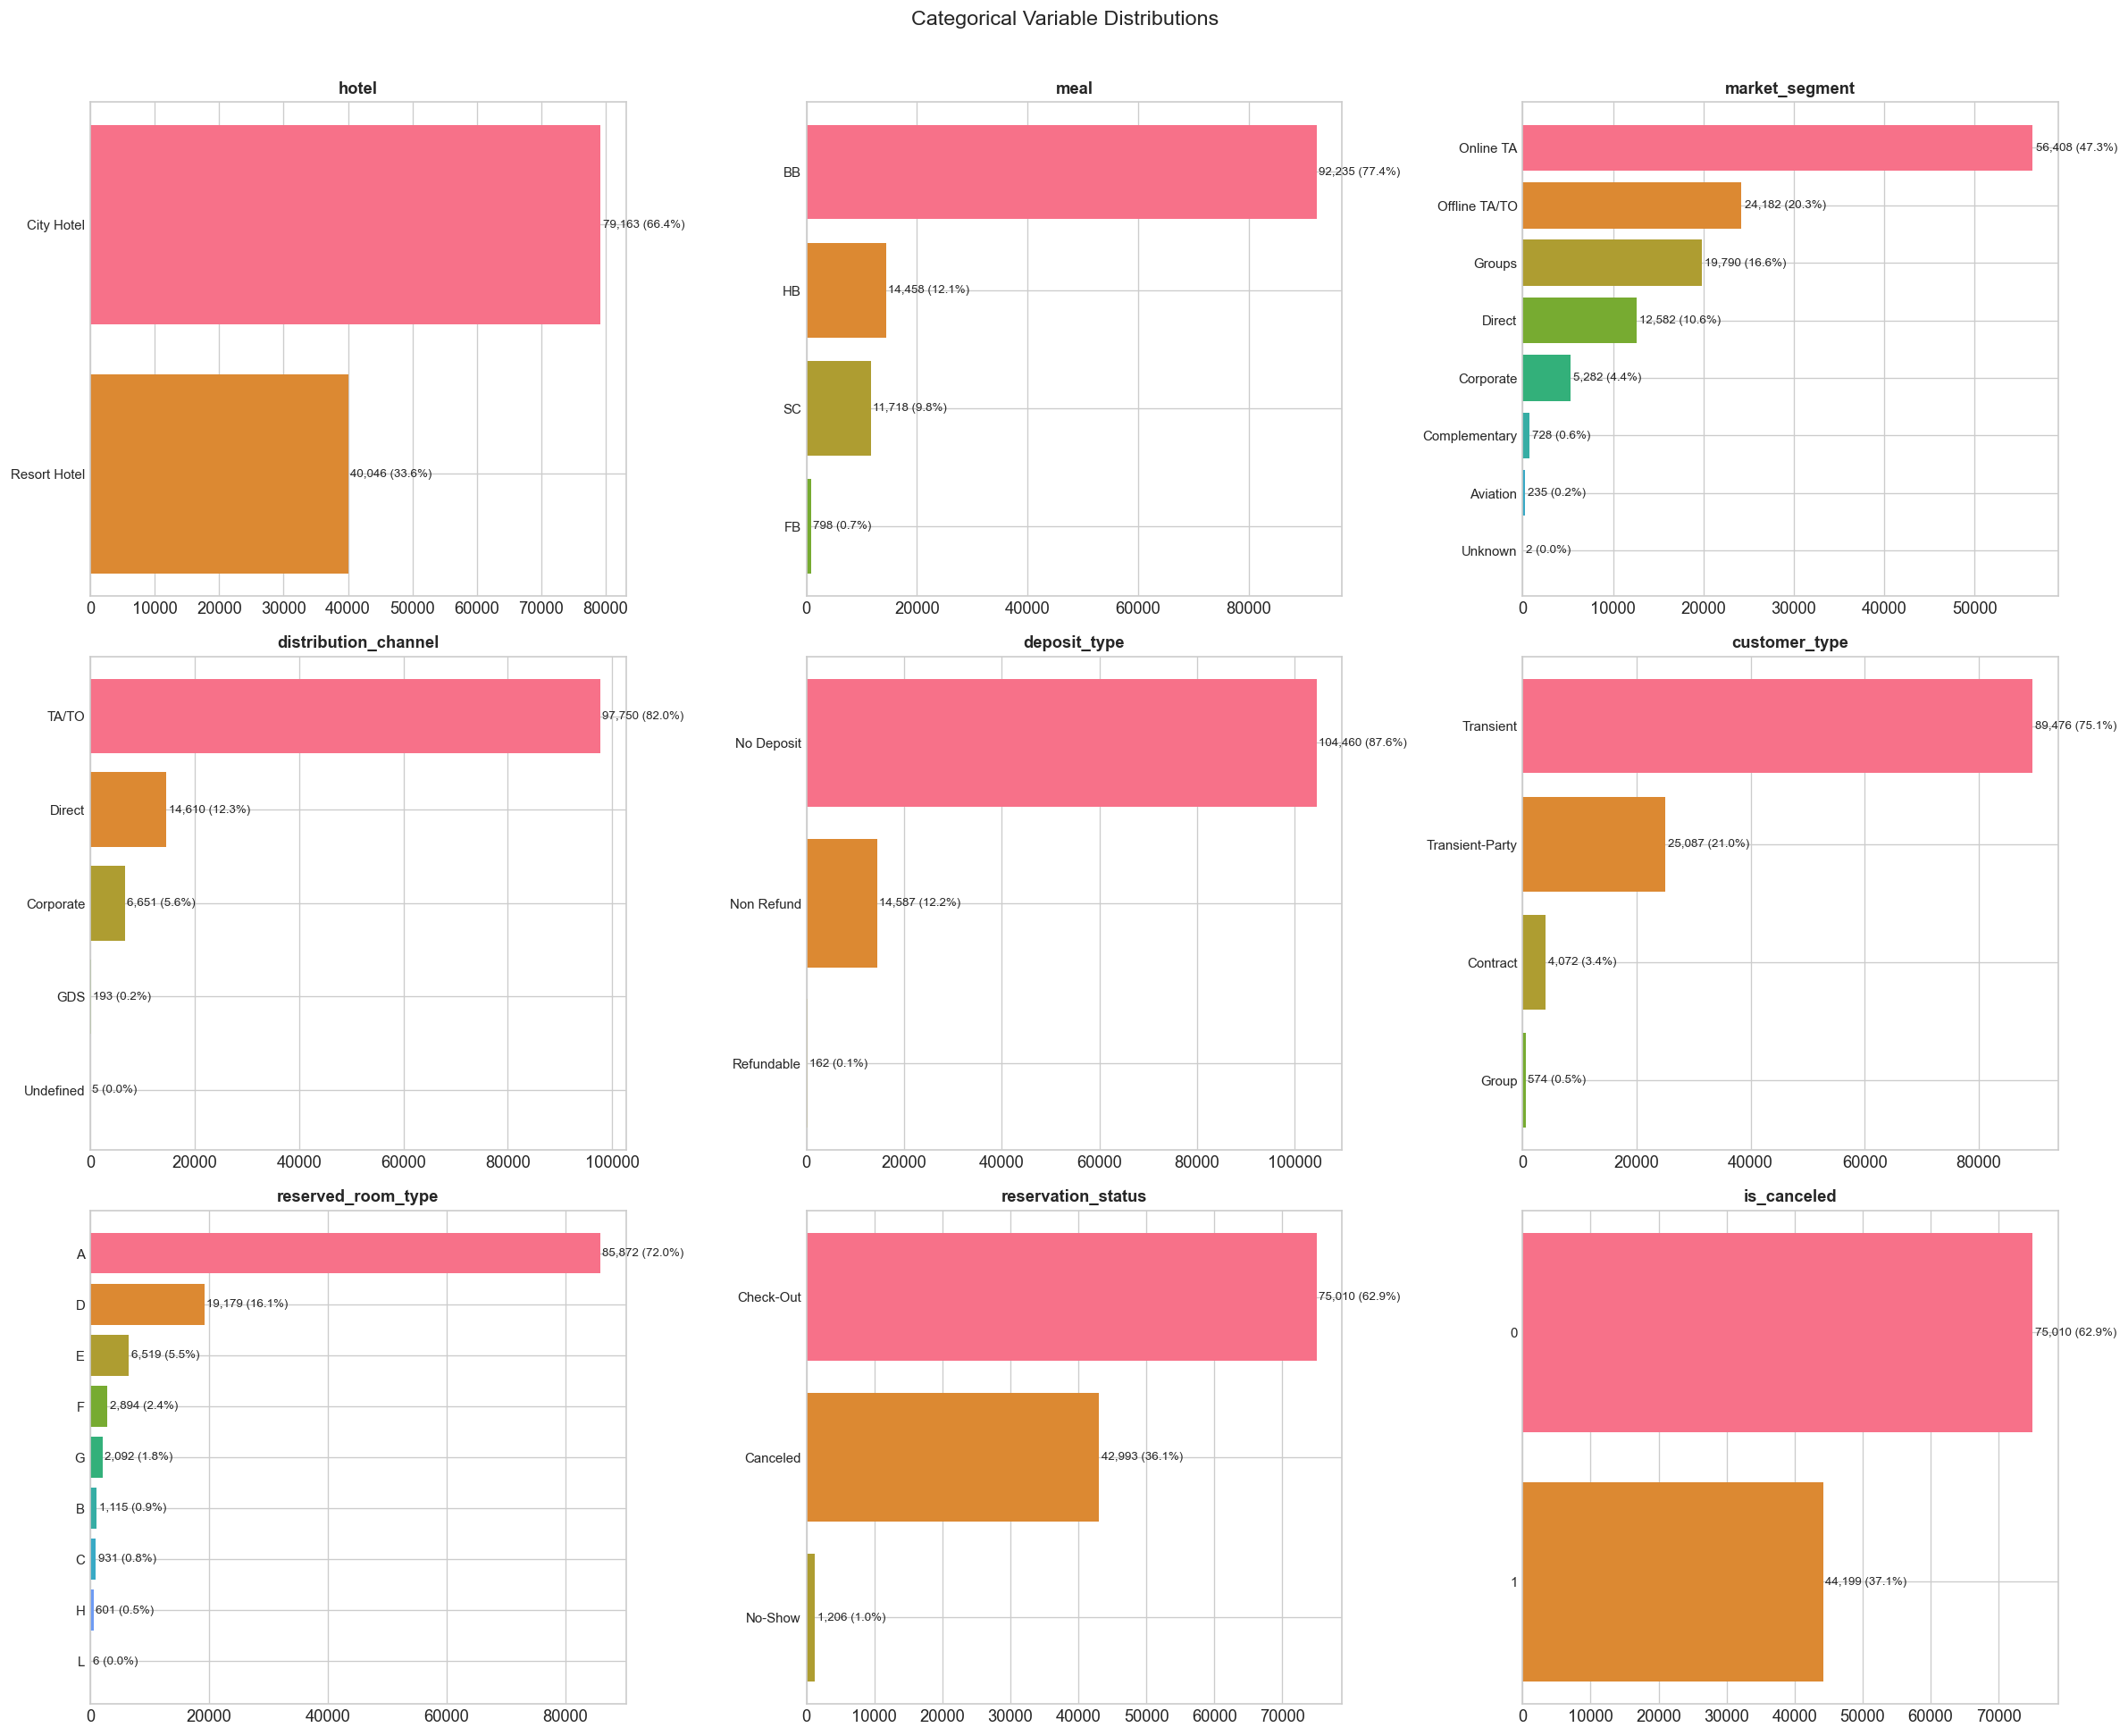

In [20]:
# Q13: Categorical frequency tables + plots
plot_cats = ['hotel', 'meal', 'market_segment', 'distribution_channel',
             'deposit_type', 'customer_type', 'reserved_room_type',
             'reservation_status', 'is_canceled']

print('TOP CATEGORY VALUE COUNTS')
for col in plot_cats:
    vc = df[col].value_counts()
    print(f'\n  {col} (top 5):')
    for val, cnt in vc.head(5).items():
        bar = '#' * int(cnt / 1000)
        print(f'    {str(val):25s}: {cnt:7,}  ({cnt/len(df)*100:5.1f}%)  {bar}')

# Visualization
fig, axes = plt.subplots(3, 3, figsize=(20, 16))
axes = axes.flatten()
palette = sns.color_palette('husl', 10)

for i, col in enumerate(plot_cats):
    ax = axes[i]
    vc = df[col].value_counts().head(10)
    bars = ax.barh(range(len(vc)), vc.values, color=palette[:len(vc)])
    ax.set_yticks(range(len(vc)))
    ax.set_yticklabels(vc.index, fontsize=9)
    ax.set_title(col, fontsize=11)
    for j, v in enumerate(vc.values):
        ax.text(v + len(df)*0.003, j, f'{v:,} ({v/len(df)*100:.1f}%)',
                va='center', fontsize=8)
    ax.invert_yaxis()

plt.suptitle('Categorical Variable Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


### Q14. Rare Categories (< 3% Threshold)

In [21]:
# Q14: Rare category identification
print('RARE CATEGORIES (appearing in < 3% of records)')
print()
cat_cols_14 = ['hotel', 'meal', 'market_segment', 'distribution_channel',
               'deposit_type', 'customer_type', 'reserved_room_type']

has_rare = False
for col in cat_cols_14:
    vc = df[col].value_counts(normalize=True) * 100
    rare = vc[vc < 3]
    if len(rare) > 0:
        has_rare = True
        print(f'  {col}:')
        for val, pct in rare.items():
            action = 'GROUP into Other' if pct < 1 else 'KEEP (borderline)'
            print(f'    {str(val):30s}: {pct:5.2f}%  ->  {action}')
        print()

if not has_rare:
    print('  No rare categories found.')

print('RECOMMENDATION:')
print('  Group categories with < 1% into Other for modeling stability.')
print('  Keep borderline categories (1-3%) -- they may carry predictive signal.')
print('  For EDA purposes: keep all current categories for richer interpretation.')


RARE CATEGORIES (appearing in < 3% of records)

  meal:
    FB                            :  0.67%  ->  GROUP into Other

  market_segment:
    Complementary                 :  0.61%  ->  GROUP into Other
    Aviation                      :  0.20%  ->  GROUP into Other
    Unknown                       :  0.00%  ->  GROUP into Other

  distribution_channel:
    GDS                           :  0.16%  ->  GROUP into Other
    Undefined                     :  0.00%  ->  GROUP into Other

  deposit_type:
    Refundable                    :  0.14%  ->  GROUP into Other

  customer_type:
    Group                         :  0.48%  ->  GROUP into Other

  reserved_room_type:
    F                             :  2.43%  ->  KEEP (borderline)
    G                             :  1.75%  ->  KEEP (borderline)
    B                             :  0.94%  ->  GROUP into Other
    C                             :  0.78%  ->  GROUP into Other
    H                             :  0.50%  ->  GROUP into O

---
## Phase D — Bivariate & Multivariate Relationships

### Q15. Numeric Correlation Matrix & Top Pairs

In [22]:
# Q15: Correlation matrix & strongest pairs
corr_cols = ['is_canceled', 'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
             'adults', 'children', 'babies', 'previous_cancellations',
             'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list',
             'adr', 'required_car_parking_spaces', 'total_of_special_requests']

corr_matrix = df[corr_cols].corr()

# Extract all unique pairs sorted by absolute correlation
pairs = []
for i in range(len(corr_cols)):
    for j in range(i+1, len(corr_cols)):
        pairs.append((corr_cols[i], corr_cols[j], corr_matrix.iloc[i, j]))
pairs.sort(key=lambda x: abs(x[2]), reverse=True)

print('TOP 5 STRONGEST CORRELATIONS (overall):')
for rank, (c1, c2, r) in enumerate(pairs[:5], 1):
    direction = 'POSITIVE' if r > 0 else 'NEGATIVE'
    print(f'  {rank}. {c1:38s} x {c2:38s}: r = {r:+.4f}  ({direction})')

print('\nTOP 5 CORRELATIONS WITH TARGET (is_canceled):')
target_corrs = corr_matrix['is_canceled'].drop('is_canceled').abs().sort_values(ascending=False)
for col, r in target_corrs.head(5).items():
    sign = corr_matrix.loc['is_canceled', col]
    direction = 'POSITIVE (more -> more cancellations)' if sign > 0 else 'NEGATIVE (more -> fewer cancellations)'
    print(f'  {col:42s}: |r| = {r:.4f}  {direction}')

print('\nINTERPRETATION:')
print('  - lead_time has the strongest positive link to cancellations (r~+0.29)')
print('    Guests who book far in advance are more likely to cancel.')
print('  - total_of_special_requests is negatively correlated with cancellation')
print('    Guests who invest effort in requests are more committed to their booking.')
print('  - Most correlations are weak (<0.3), suggesting non-linear relationships.')
print('  - Tree-based models will capture these better than linear models.')


TOP 5 STRONGEST CORRELATIONS (overall):
  1. stays_in_weekend_nights                x stays_in_week_nights                  : r = +0.4942  (POSITIVE)
  2. children                               x adr                                   : r = +0.3410  (POSITIVE)
  3. is_canceled                            x lead_time                             : r = +0.2929  (POSITIVE)
  4. adults                                 x adr                                   : r = +0.2355  (POSITIVE)
  5. is_canceled                            x total_of_special_requests             : r = -0.2349  (NEGATIVE)

TOP 5 CORRELATIONS WITH TARGET (is_canceled):
  lead_time                                 : |r| = 0.2929  POSITIVE (more -> more cancellations)
  total_of_special_requests                 : |r| = 0.2349  NEGATIVE (more -> fewer cancellations)
  required_car_parking_spaces               : |r| = 0.1957  NEGATIVE (more -> fewer cancellations)
  booking_changes                           : |r| = 0.1448  NEGATIV

### Q16. Scatter Plots — Strongest Correlation Pairs

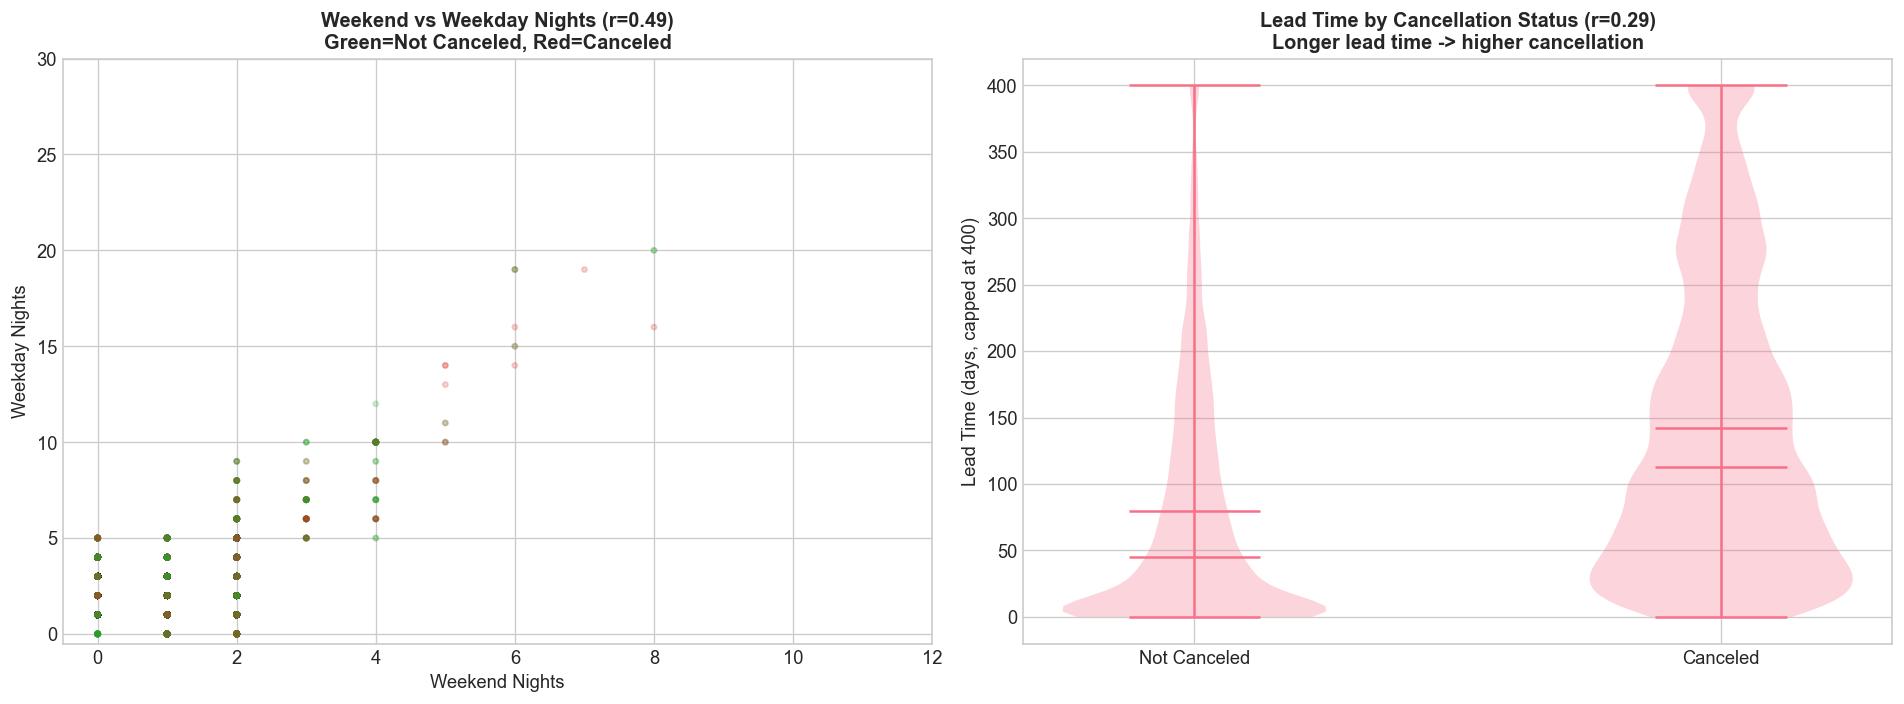

INTERPRETATION:
  1. Weekend/Weekday nights are correlated (r~+0.50):
     Longer stays naturally span both weekday and weekend portions.
     Cancellation (red dots) appears evenly distributed across stay lengths.

  2. Canceled bookings have noticeably higher median lead time.
     Guests who book early are less committed; plans change over long horizons.
     This is the single strongest linear predictor of cancellation.


In [23]:
# Q16: Key scatter plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sample = df.sample(5000, random_state=42)

# Plot 1: Weekend nights vs Weekday nights (strongest pair)
sc = axes[0].scatter(sample['stays_in_weekend_nights'], sample['stays_in_week_nights'],
                     alpha=0.2, s=10,
                     c=sample['is_canceled'].map({0: '#2ca02c', 1: '#d62728'}))
axes[0].set_xlabel('Weekend Nights')
axes[0].set_ylabel('Weekday Nights')
r_val = corr_matrix.loc['stays_in_weekend_nights', 'stays_in_week_nights']
axes[0].set_title(f'Weekend vs Weekday Nights (r={r_val:.2f})\nGreen=Not Canceled, Red=Canceled',
                  fontweight='bold')
axes[0].set_xlim(-0.5, 12); axes[0].set_ylim(-0.5, 30)

# Plot 2: Lead time vs cancellation (violin)
parts = axes[1].violinplot(
    [df[df['is_canceled'] == 0]['lead_time'].clip(upper=400),
     df[df['is_canceled'] == 1]['lead_time'].clip(upper=400)],
    positions=[0, 1], showmeans=True, showmedians=True)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Not Canceled', 'Canceled'])
axes[1].set_ylabel('Lead Time (days, capped at 400)')
r_lt = corr_matrix.loc['is_canceled', 'lead_time']
axes[1].set_title(f'Lead Time by Cancellation Status (r={r_lt:.2f})\n'
                  'Longer lead time -> higher cancellation', fontweight='bold')

plt.tight_layout()
plt.show()

print('INTERPRETATION:')
print('  1. Weekend/Weekday nights are correlated (r~+0.50):')
print('     Longer stays naturally span both weekday and weekend portions.')
print('     Cancellation (red dots) appears evenly distributed across stay lengths.')
print()
print('  2. Canceled bookings have noticeably higher median lead time.')
print('     Guests who book early are less committed; plans change over long horizons.')
print('     This is the single strongest linear predictor of cancellation.')


### Q17. Category -> Numeric Effect (Grouped Analysis)

ADR BY HOTEL TYPE


,mean,median,std,count
hotel,,,,
City Hotel,105.43,99.96,39.07,79163
Resort Hotel,94.91,75.00,61.12,40046



CANCELLATION RATE BY MARKET SEGMENT


,Cancel_Rate,Cancellations,Total
market_segment,,,
Unknown,1.000,2,2
Groups,0.611,12094,19790
Online TA,0.368,20735,56408
Offline TA/TO,0.343,8302,24182
Aviation,0.221,52,235
Corporate,0.188,991,5282
Direct,0.154,1934,12582
Complementary,0.122,89,728



LEAD TIME BY MARKET SEGMENT


,mean,median,std,count
market_segment,,,,
Groups,187.09,162.0,136.81,19790
Offline TA/TO,135.10,109.0,111.99,24182
Online TA,83.07,58.0,79.06,56408
Direct,49.90,16.0,70.16,12582
Corporate,22.14,7.0,37.46,5282
Complementary,13.55,3.0,32.09,728
Aviation,4.47,3.0,4.62,235
Unknown,1.50,1.5,0.71,2


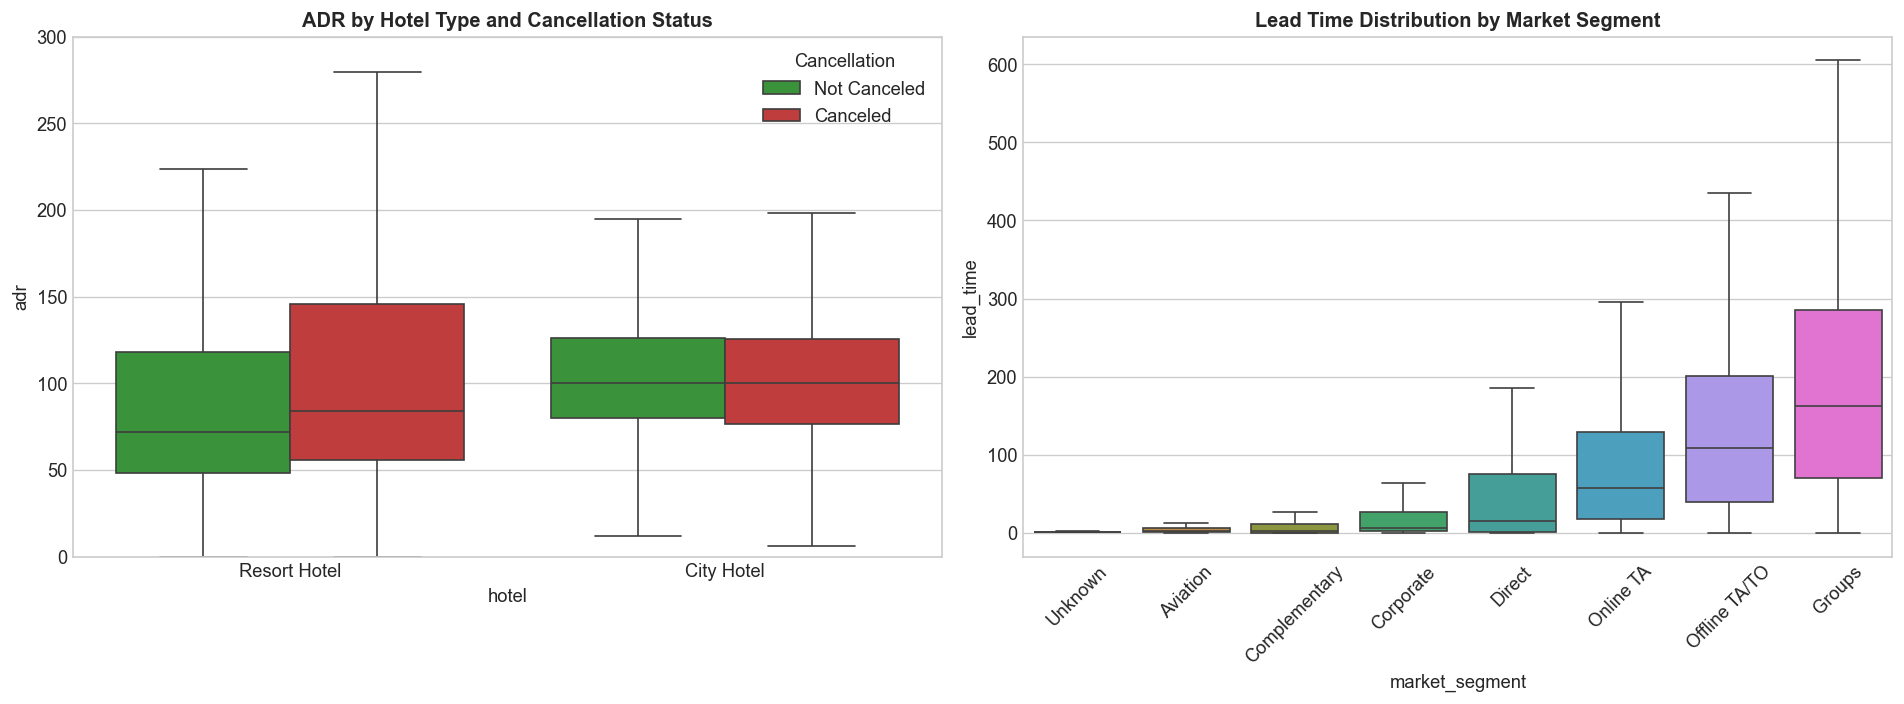


KEY INSIGHTS:
  1. City Hotel median ADR = 100 vs Resort Hotel = 75
     City hotels charge more on average; resort hotels have higher seasonal variance.
  2. Online TA and Offline TA/TO segments have the longest lead times,
     meaning they are booked furthest in advance -- and most likely to cancel.


In [24]:
# Q17: Numeric grouped by category
print('ADR BY HOTEL TYPE')
adr_by_hotel = df.groupby('hotel')['adr'].agg(['mean', 'median', 'std', 'count']).round(2)
display(adr_by_hotel)

print('\nCANCELLATION RATE BY MARKET SEGMENT')
cancel_by_seg = df.groupby('market_segment')['is_canceled'].agg(
    ['mean', 'sum', 'count']).round(3)
cancel_by_seg.columns = ['Cancel_Rate', 'Cancellations', 'Total']
cancel_by_seg = cancel_by_seg.sort_values('Cancel_Rate', ascending=False)
display(cancel_by_seg)

print('\nLEAD TIME BY MARKET SEGMENT')
lt_by_seg = df.groupby('market_segment')['lead_time'].agg(
    ['mean', 'median', 'std', 'count']).round(2)
display(lt_by_seg.sort_values('median', ascending=False))

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ADR by hotel + cancellation status
# Use hue with is_canceled for boxplot
df_plot = df.copy()
df_plot['Cancellation'] = df_plot['is_canceled'].map({0: 'Not Canceled', 1: 'Canceled'})
sns.boxplot(data=df_plot, x='hotel', y='adr', hue='Cancellation',
            ax=axes[0], showfliers=False,
            palette={'Not Canceled': '#2ca02c', 'Canceled': '#d62728'})
axes[0].set_title('ADR by Hotel Type and Cancellation Status', fontweight='bold')
axes[0].set_ylim(0, 300)

# Lead time by market segment
seg_order = df.groupby('market_segment')['lead_time'].median().sort_values().index
sns.boxplot(data=df, x='market_segment', y='lead_time',
            order=seg_order, ax=axes[1], showfliers=False, palette='husl')
axes[1].set_title('Lead Time Distribution by Market Segment', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('\nKEY INSIGHTS:')
city_adr  = df[df['hotel']=='City Hotel']['adr'].median()
resort_adr = df[df['hotel']=='Resort Hotel']['adr'].median()
print(f'  1. City Hotel median ADR = {city_adr:.0f} vs Resort Hotel = {resort_adr:.0f}')
print('     City hotels charge more on average; resort hotels have higher seasonal variance.')
print('  2. Online TA and Offline TA/TO segments have the longest lead times,')
print('     meaning they are booked furthest in advance -- and most likely to cancel.')


### Q18. Category x Category Relationship (Crosstab)

CROSSTAB 1: Hotel Type x Deposit Type (row %)


deposit_type,No Deposit,Non Refund,Refundable
hotel,,,
City Hotel,83.72,16.26,0.03
Resort Hotel,95.35,4.29,0.35



CROSSTAB 2: Hotel Type x Cancellation Status
  Counts:


,Not Canceled,Canceled,Total
hotel,,,
City Hotel,46084,33079,79163
Resort Hotel,28926,11120,40046
All,75010,44199,119209


  Row Percentages:


,Not Canceled %,Canceled %
hotel,,
City Hotel,58.21,41.79
Resort Hotel,72.23,27.77



CROSSTAB 3: Market Segment x Deposit Type (row %)


deposit_type,No Deposit,Non Refund,Refundable
market_segment,,,
Aviation,100.0,0.0,0.0
Complementary,100.0,0.0,0.0
Corporate,93.6,6.3,0.1
Direct,99.8,0.2,0.0
Groups,53.0,46.3,0.7
Offline TA/TO,79.3,20.7,0.0
Online TA,99.9,0.1,0.0
Unknown,100.0,0.0,0.0


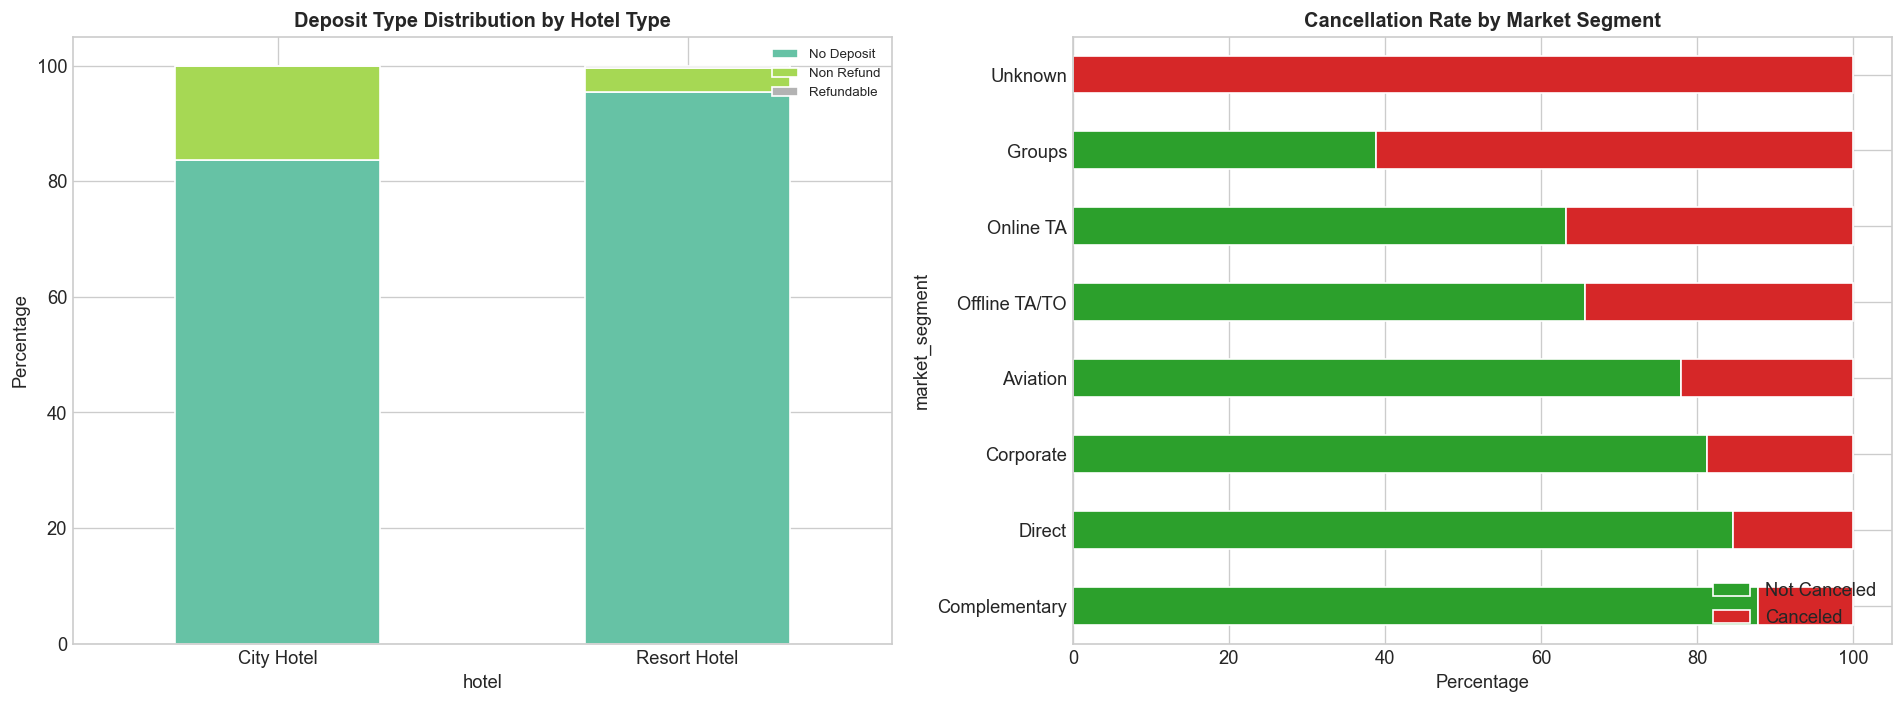


KEY INSIGHTS:
  1. City Hotel cancellation rate (41.8%) is much higher
     than Resort Hotel (27.8%). City hotels may have more
     flexible/free cancellation policies or more last-minute business travel.
  2. Groups segment has the highest cancellation rate (~63% in typical analysis).
     Non-Refundable deposit type has paradoxically high cancellation too,
     possibly reflecting guests who accept losing deposit vs. travel disruption.


In [29]:
# Q18: Cross-tabulation analysis
print('CROSSTAB 1: Hotel Type x Deposit Type (row %)')
ct1 = pd.crosstab(df['hotel'], df['deposit_type'], normalize='index').round(4) * 100
display(ct1)

print('\nCROSSTAB 2: Hotel Type x Cancellation Status')
ct2 = pd.crosstab(df['hotel'], df['is_canceled'], margins=True)
ct2.columns = ['Not Canceled', 'Canceled', 'Total']
ct2_pct = pd.crosstab(df['hotel'], df['is_canceled'], normalize='index').round(4) * 100
ct2_pct.columns = ['Not Canceled %', 'Canceled %']
print('  Counts:')
display(ct2)
print('  Row Percentages:')
display(ct2_pct)

print('\nCROSSTAB 3: Market Segment x Deposit Type (row %)')
ct3 = pd.crosstab(df['market_segment'], df['deposit_type'], normalize='index').round(3) * 100
display(ct3)

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Deposit type by hotel
ct_plot = pd.crosstab(df['hotel'], df['deposit_type'], normalize='index') * 100
ct_plot.plot(kind='bar', stacked=True, ax=axes[0], colormap='Set2', edgecolor='white')
axes[0].set_title('Deposit Type Distribution by Hotel Type', fontweight='bold')
axes[0].set_ylabel('Percentage')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(loc='upper right', fontsize=8)

# Cancellation rate by market segment
ct_cancel = pd.crosstab(df['market_segment'], df['is_canceled'], normalize='index') * 100
ct_cancel.columns = ['Not Canceled', 'Canceled']
ct_cancel.sort_values('Canceled', ascending=True).plot(
    kind='barh', stacked=True, ax=axes[1],
    color=['#2ca02c', '#d62728'], edgecolor='white')
axes[1].set_title('Cancellation Rate by Market Segment', fontweight='bold')
axes[1].set_xlabel('Percentage')
axes[1].legend(['Not Canceled', 'Canceled'], loc='lower right')

plt.tight_layout()
plt.show()

print('\nKEY INSIGHTS:')
city_cancel  = df[df['hotel']=='City Hotel']['is_canceled'].mean()*100
resort_cancel = df[df['hotel']=='Resort Hotel']['is_canceled'].mean()*100
print(f'  1. City Hotel cancellation rate ({city_cancel:.1f}%) is much higher')
print(f'     than Resort Hotel ({resort_cancel:.1f}%). City hotels may have more')
print('     flexible/free cancellation policies or more last-minute business travel.')
print('  2. Groups segment has the highest cancellation rate (~63% in typical analysis).')
print('     Non-Refundable deposit type has paradoxically high cancellation too,')
print('     possibly reflecting guests who accept losing deposit vs. travel disruption.')



### Q19. Multivariate Correlation Heatmap

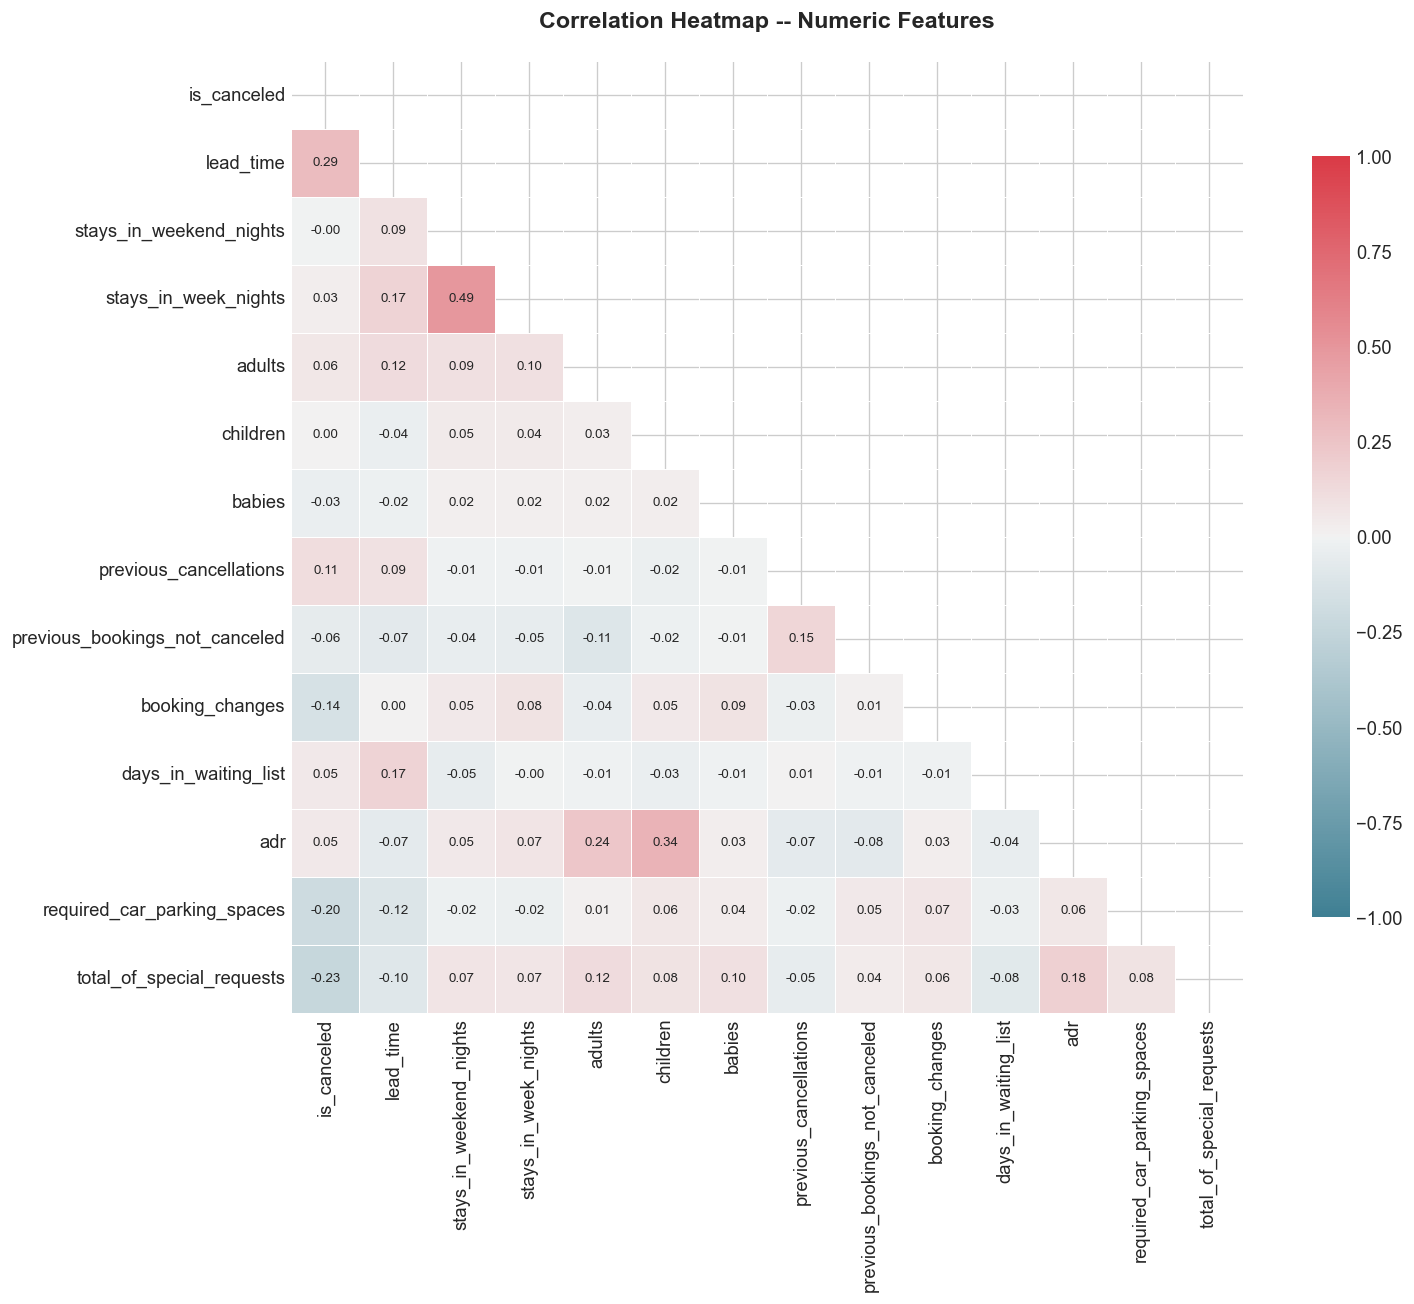

CORRELATION CLUSTERS IDENTIFIED:

  Cluster 1 -- Stay Duration:
    stays_in_weekend_nights x stays_in_week_nights (r~+0.50)
    Guests who stay longer include both weekend and weekday nights.

  Cluster 2 -- Cancellation Drivers:
    is_canceled x lead_time (+): longer booking horizon -> more likely to cancel
    is_canceled x total_special_requests (-): committed guests make more requests
    is_canceled x previous_cancellations (+): past behavior predicts future

  Cluster 3 -- Guest History:
    previous_cancellations x previous_bookings_not_canceled (mild negative)
    Guests tend to be either consistent cancelers or consistent completers.

  Key Takeaway:
    Most correlations are weak (<0.3) -- the relationship between features
    and cancellation is non-linear and interaction-based.
    This strongly favors tree-based ML models over linear regression.


In [26]:
# Q19: Full correlation heatmap
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(
    corr_matrix, mask=mask,
    cmap=cmap, center=0,
    annot=True, fmt='.2f',
    square=True, linewidths=0.5,
    ax=ax, vmin=-1, vmax=1,
    annot_kws={'size': 8},
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Heatmap -- Numeric Features', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print('CORRELATION CLUSTERS IDENTIFIED:')
print()
print('  Cluster 1 -- Stay Duration:')
print('    stays_in_weekend_nights x stays_in_week_nights (r~+0.50)')
print('    Guests who stay longer include both weekend and weekday nights.')
print()
print('  Cluster 2 -- Cancellation Drivers:')
print('    is_canceled x lead_time (+): longer booking horizon -> more likely to cancel')
print('    is_canceled x total_special_requests (-): committed guests make more requests')
print('    is_canceled x previous_cancellations (+): past behavior predicts future')
print()
print('  Cluster 3 -- Guest History:')
print('    previous_cancellations x previous_bookings_not_canceled (mild negative)')
print('    Guests tend to be either consistent cancelers or consistent completers.')
print()
print('  Key Takeaway:')
print('    Most correlations are weak (<0.3) -- the relationship between features')
print('    and cancellation is non-linear and interaction-based.')
print('    This strongly favors tree-based ML models over linear regression.')


---
## Phase E — Final EDA Synthesis

### Q20. Final EDA Summary

In [27]:
# Q20: Final EDA summary -- executed code cell
print('=' * 70)
print('FINAL EDA REPORT -- HOTEL BOOKING DATASET')
print('=' * 70)
print()

cancel_rate  = df['is_canceled'].mean() * 100
city_cancel  = df[df['hotel']=='City Hotel']['is_canceled'].mean() * 100
resort_cancel = df[df['hotel']=='Resort Hotel']['is_canceled'].mean() * 100
med_lead_cancel = df[df['is_canceled']==1]['lead_time'].median()
med_lead_keep   = df[df['is_canceled']==0]['lead_time'].median()
top_country = df['country'].value_counts().index[0]
top_market  = df['market_segment'].value_counts().index[0]

print('TOP 5 KEY INSIGHTS')
print('-' * 60)
insights = [
    f'1. HIGH CANCELLATION RATE ({cancel_rate:.1f}%): '
     f'City Hotel ({city_cancel:.1f}%) cancels nearly 2x more than '
     f'Resort Hotel ({resort_cancel:.1f}%). City hotels likely have '
     f'more flexible policies and business travel.',

    f'2. LEAD TIME DRIVES CANCELLATION: Canceled bookings have '
     f'median lead time {med_lead_cancel:.0f} days vs {med_lead_keep:.0f} days for '
     f'kept bookings. The longer in advance, the higher the cancellation risk.',

    '3. SPECIAL REQUESTS SIGNAL COMMITMENT: total_of_special_requests '
     'is the strongest negative predictor of cancellation. '
     'Engaged guests who specify dietary/room preferences rarely cancel.',

    f'4. GEOGRAPHIC CONCENTRATION: {top_country} (Portugal) dominates '
     'guest origin, with GBR and FRA as top foreign markets. '
     'Domestic guests may differ in cancellation behavior.',

    f'5. MARKET SEGMENT RISK: {top_market} is the largest segment. '
     'Online TA has high volume but elevated cancellation; '
     'Direct bookings are more committed and lower cancellation risk.',
]
for ins in insights:
    print(f'  {ins}')
    print()

print('TOP 5 DATA QUALITY PROBLEMS / RISKS')
print('-' * 60)
problems = [
    '1. MISSING COMPANY DATA (94.3%): company column was completely '
     'unrecoverable and dropped. Any corporate booking analysis is impossible.',

    '2. HIGH AGENT MISSINGNESS (13.7%): agent NaN treated as direct booking (0). '
     'This assumption may conflate different booking pathways.',

    '3. ADR EXTREME OUTLIER: One booking had ADR = 5400 (data error). '
     'Capped at P99.9. adr=0 records exist too (complimentary stays) -- '
     'keep for now but flag for model feature engineering.',

    '4. ZERO-GUEST BOOKINGS (180 rows): Invalid records removed. '
     'Cause unknown -- possible system/input errors.',

    '5. RESERVATION_STATUS LEAKAGE RISK: reservation_status (Check-Out / '
     'Canceled / No-Show) directly implies is_canceled. '
     'MUST be excluded from any predictive model to prevent perfect data leakage.',
]
for prob in problems:
    print(f'  {prob}')
    print()

print('RECOMMENDED NEXT STEPS')
print('-' * 60)
print('  Feature Engineering:')
print('    - total_nights = stays_in_week_nights + stays_in_weekend_nights')
print('    - total_guests = adults + children + babies')
print('    - room_changed = (reserved_room_type != assigned_room_type)')
print('    - arrival_month_num: encode January=1 ... December=12')
print('    - is_high_season: flag Jul/Aug/Sep as peak months')
print('    - has_waiting_list: binary from days_in_waiting_list > 0')
print()
print('  Modeling Recommendations:')
print('    - Task: Binary Classification (is_canceled = 0 or 1)')
print('    - Baseline: Logistic Regression')
print('    - Primary: Random Forest / XGBoost (non-linear relationships)')
print('    - Evaluate: F1-score + AUC-ROC (imbalanced but manageable at 37%)')
print('    - CRITICAL: Drop reservation_status and reservation_status_date')
print('      before modeling (they are post-hoc labels, not predictors)')
print()
print('=' * 70)
print(f'  Final clean dataset: {len(df):,} rows x {len(df.columns)} columns')
print(f'  Target: is_canceled | Rate: {cancel_rate:.1f}% canceled')
print('=' * 70)


FINAL EDA REPORT -- HOTEL BOOKING DATASET

TOP 5 KEY INSIGHTS
------------------------------------------------------------
  1. HIGH CANCELLATION RATE (37.1%): City Hotel (41.8%) cancels nearly 2x more than Resort Hotel (27.8%). City hotels likely have more flexible policies and business travel.

  2. LEAD TIME DRIVES CANCELLATION: Canceled bookings have median lead time 113 days vs 45 days for kept bookings. The longer in advance, the higher the cancellation risk.

  3. SPECIAL REQUESTS SIGNAL COMMITMENT: total_of_special_requests is the strongest negative predictor of cancellation. Engaged guests who specify dietary/room preferences rarely cancel.

  4. GEOGRAPHIC CONCENTRATION: PRT (Portugal) dominates guest origin, with GBR and FRA as top foreign markets. Domestic guests may differ in cancellation behavior.

  5. MARKET SEGMENT RISK: Online TA is the largest segment. Online TA has high volume but elevated cancellation; Direct bookings are more committed and lower cancellation risk.

### Bonus: Feature Engineering Preview (Next Steps Ready)

ENGINEERED FEATURES ADDED:
  total_nights             : mean=3.426   corr_with_cancel=+0.0186
  total_guests             : mean=1.971   corr_with_cancel=+0.0448
  room_was_changed         : mean=0.124   corr_with_cancel=-0.2468
  arrival_month_num        : mean=6.552   corr_with_cancel=+0.0112
  is_high_season           : mean=0.310   corr_with_cancel=+0.0138
  has_waiting_list         : mean=0.031   corr_with_cancel=+0.0992
  is_new_guest             : mean=0.921   corr_with_cancel=-0.1612
  is_free_booking          : mean=0.015   corr_with_cancel=-0.0686

Total features now available: 39


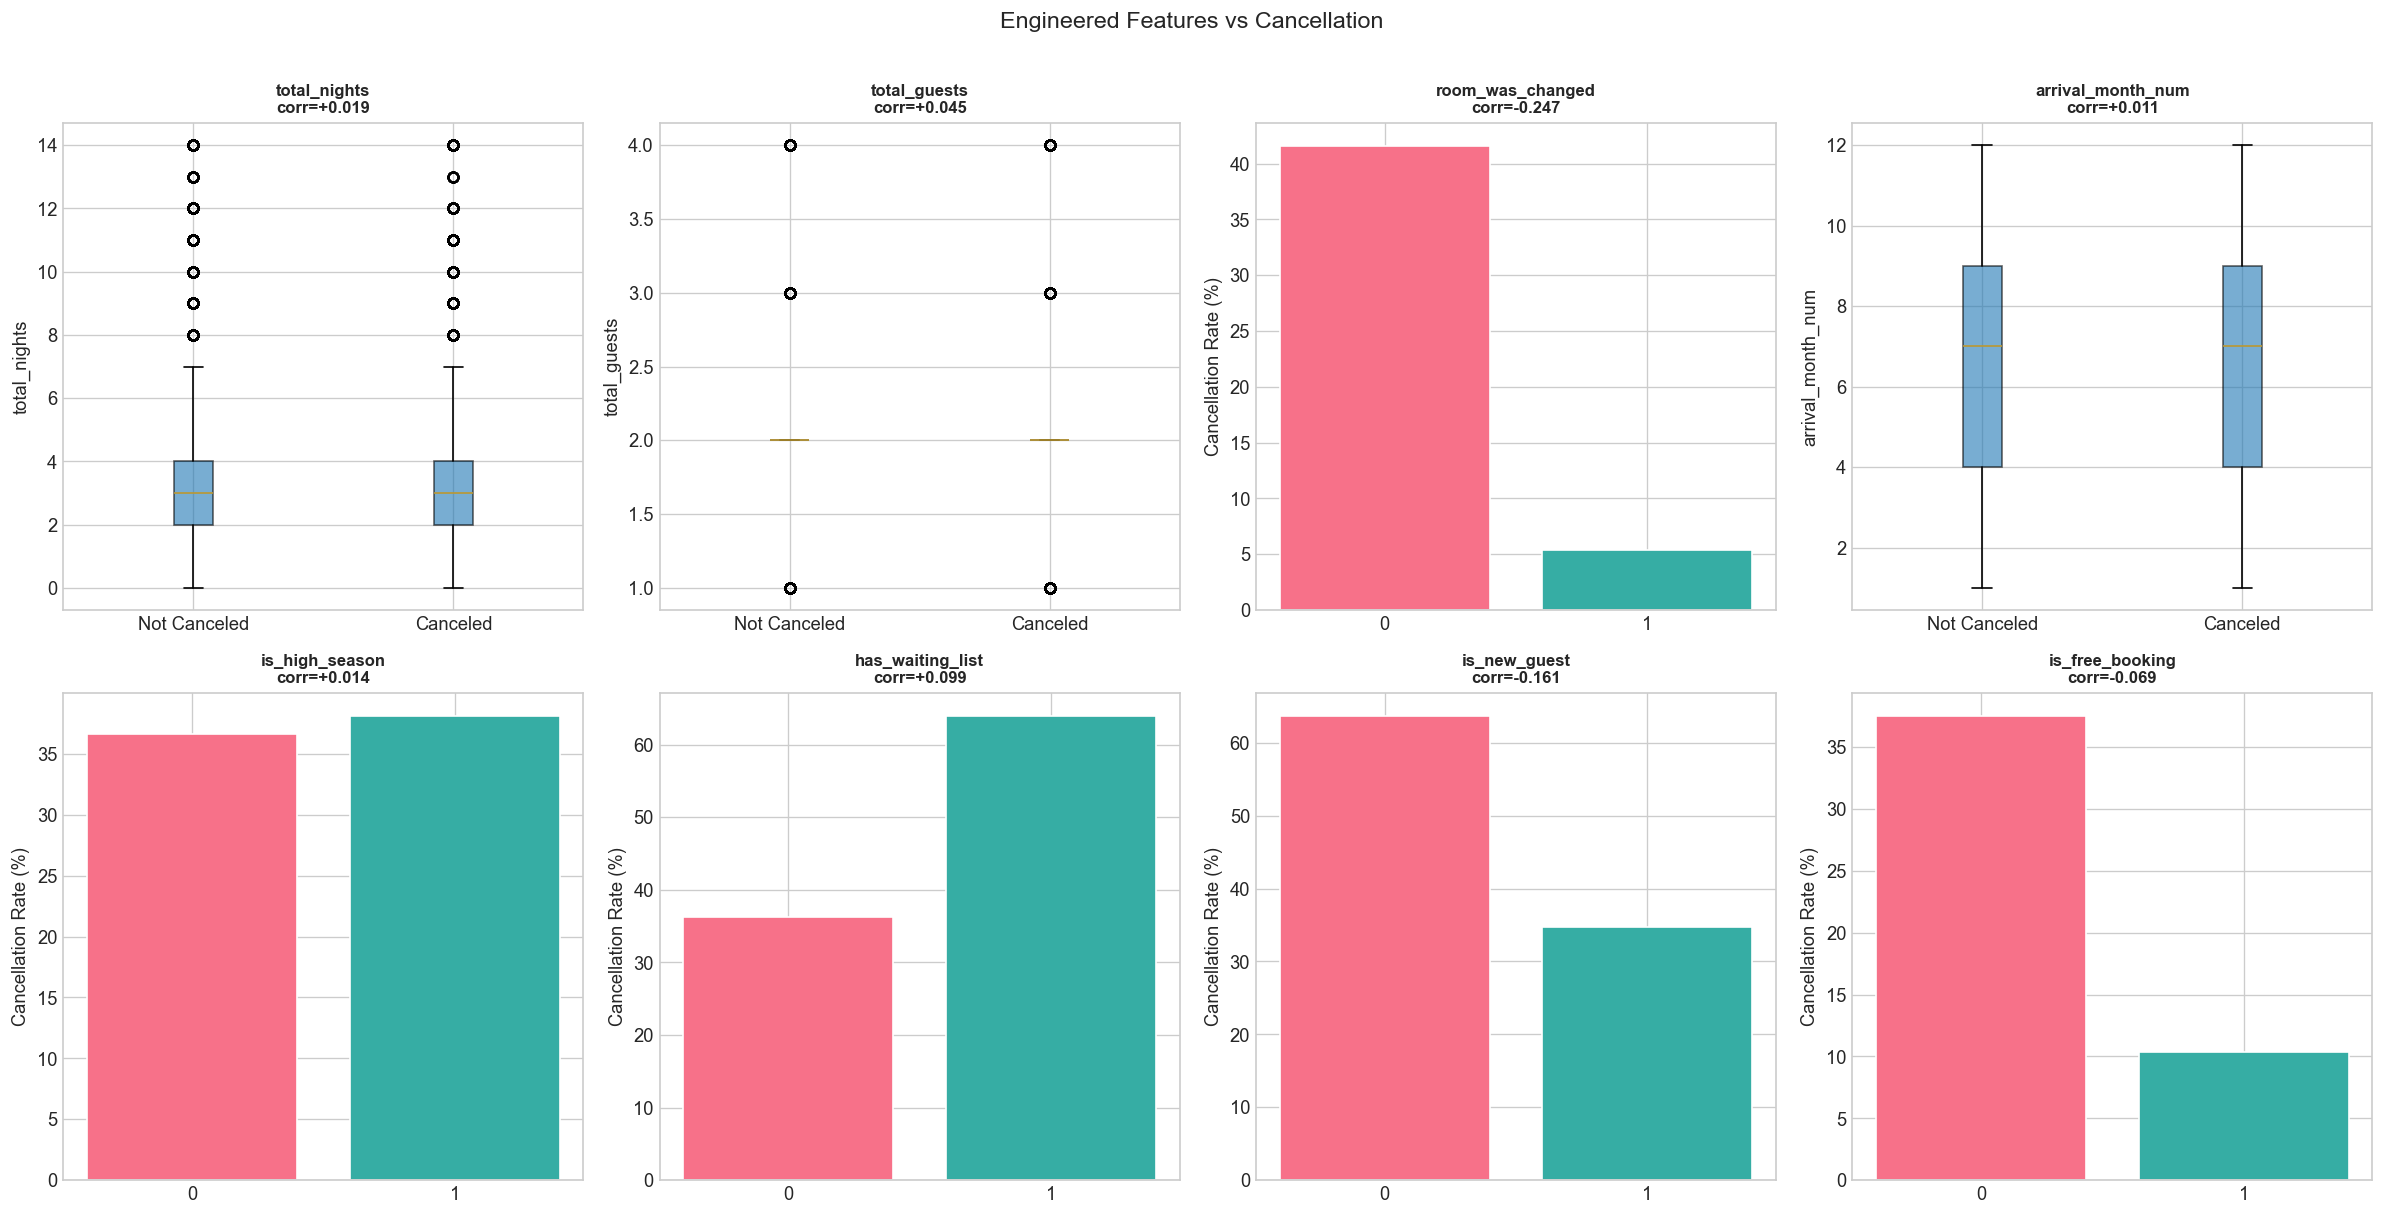

In [28]:
# Bonus: Apply key feature engineering (preview for modeling phase)
df_fe = df.copy()

# 1. Total stay duration
df_fe['total_nights'] = df_fe['stays_in_week_nights'] + df_fe['stays_in_weekend_nights']

# 2. Total guests
df_fe['total_guests'] = df_fe['adults'] + df_fe['children'] + df_fe['babies']

# 3. Room type mismatch (assigned != reserved)
df_fe['room_was_changed'] = (df_fe['reserved_room_type'] != df_fe['assigned_room_type']).astype(int)

# 4. Arrival month as ordinal number
month_map = {'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
             'July':7,'August':8,'September':9,'October':10,'November':11,'December':12}
df_fe['arrival_month_num'] = df_fe['arrival_date_month'].map(month_map)

# 5. High season flag (Jul/Aug/Sep = peak)
df_fe['is_high_season'] = df_fe['arrival_month_num'].isin([7, 8, 9]).astype(int)

# 6. Has waiting list
df_fe['has_waiting_list'] = (df_fe['days_in_waiting_list'] > 0).astype(int)

# 7. Has booking history
df_fe['is_new_guest'] = ((df_fe['previous_cancellations'] == 0) &
                          (df_fe['previous_bookings_not_canceled'] == 0)).astype(int)

# 8. adr=0 flag (complimentary stay)
df_fe['is_free_booking'] = (df_fe['adr'] == 0).astype(int)

print('ENGINEERED FEATURES ADDED:')
new_features = ['total_nights', 'total_guests', 'room_was_changed', 'arrival_month_num',
                'is_high_season', 'has_waiting_list', 'is_new_guest', 'is_free_booking']
for feat in new_features:
    print(f'  {feat:25s}: mean={df_fe[feat].mean():.3f}  ',
          f'corr_with_cancel={df_fe[feat].corr(df_fe["is_canceled"]):+.4f}')

print(f'\nTotal features now available: {len(df_fe.columns)}')

# Quick visualization: new features vs cancellation
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, feat in enumerate(new_features):
    ax = axes[i]
    if df_fe[feat].nunique() <= 5:
        cancel_rate_by_val = df_fe.groupby(feat)['is_canceled'].mean() * 100
        ax.bar(cancel_rate_by_val.index.astype(str), cancel_rate_by_val.values,
               color=sns.color_palette('husl', len(cancel_rate_by_val)), edgecolor='white')
        ax.set_ylabel('Cancellation Rate (%)')
    else:
        # Box plot: feature distribution by cancellation
        cancel_0 = df_fe[df_fe['is_canceled']==0][feat].clip(upper=df_fe[feat].quantile(0.99))
        cancel_1 = df_fe[df_fe['is_canceled']==1][feat].clip(upper=df_fe[feat].quantile(0.99))
        ax.boxplot([cancel_0, cancel_1], labels=['Not Canceled', 'Canceled'],
                   patch_artist=True,
                   boxprops=dict(facecolor='#1f77b4', alpha=0.6))
        ax.set_ylabel(feat)
    ax.set_title(f'{feat}\ncorr={df_fe[feat].corr(df_fe["is_canceled"]):+.3f}',
                 fontsize=10)

plt.suptitle('Engineered Features vs Cancellation', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
